### Spatio-Temporal Crime Prediction (for Violent Crime)
**Aim:** Predict the probability ($P$) that a crime will occur in a specific tile at a specific time. To direct patrol units (beats) to perform "proactive presence" in these specific tiles during their shift.

### Setup


In [155]:
# Install required packages (run once if needed)
!pip install geopandas h3 xgboost scikit-learn pandas numpy matplotlib seaborn joblib contextily lightgbm shap --break-system-packages --quiet

In [73]:
# =============================================================================
# IMPORTS
# =============================================================================
# Data manipulation
import pandas as pd
import numpy as np
import geopandas as gpd
import h3
from shapely.geometry import Polygon

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as cx # Added contextily import

# Math utilities
from math import radians  # For converting degrees to radians (used in Haversine formula)

# File I/O
import json
import joblib  # For saving/loading sklearn models
import os

# Machine Learning
import xgboost as xgb  # Gradient boosting library
import lightgbm as lgb  # Gradient boosting library (fast, memory-efficient)
from sklearn.ensemble import RandomForestClassifier  # Bagging ensemble method
from catboost import CatBoostClassifier  # Gradient boosting library with native categorical support
from lightgbm import LGBMClassifier  # LightGBM classifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder  # For categorical encoding in pipelines
from sklearn.compose import ColumnTransformer  # Apply different transforms to different columns
from sklearn.pipeline import Pipeline  # Chain preprocessing + model together
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score
)

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


---
### Step 1: Load Data

We load data from two parquet files (after DatasetDownload to local drive):
- **ChicagoCrimes(20152025).parquet**: Reported crime incidents in Chicago from 2015 to 2025 (crime types, locations, dates and arrest status)
- **ChicagoCommunityArea.parquet**: Geographic and administrative information of Chicago's 77 official community areas 
- **Chicago Police Beats Boundary (API)**: Current police beat boundaries in Chicago

In [74]:
from pathlib import Path
from shapely.geometry import shape

print("="*60)
print("STEP 1: LOAD DATA")
print("="*60)

# Resolve path relative to this notebook location
notebook_dir = Path.cwd()
base_dir = notebook_dir.parent.parent  # IT5006Group
project_data_dir = base_dir / "ProjectData"

community_path = project_data_dir / "chicagocommunityarea.parquet"
crimes_path = project_data_dir / "chicagocrimes(20152025).parquet"

if not community_path.exists() or not crimes_path.exists():
    raise FileNotFoundError(
        "Could not find one or both parquet files in ProjectData.\n"
        f"Expected:\n- {community_path}\n- {crimes_path}"
    )

print(f"\nLoading data from:\n  {community_path}\n  {crimes_path}")

# Load Chicago community area lookup table
community_df = pd.read_parquet(community_path)
print(f"   {community_path.name}: {len(community_df):,} rows")

# Load Chicago crimes main dataset
crimes_df = pd.read_parquet(crimes_path)
print(f"   {crimes_path.name}: {len(crimes_df):,} rows")

# Load Chicago Police Beats boundary dataset (SODA2 API endpoint from portal)
beats_url = "https://data.cityofchicago.org/resource/n9it-hstw.json?$limit=5000"
beats_df = pd.read_json(beats_url)

if "the_geom" in beats_df.columns:
    beats_gdf = gpd.GeoDataFrame(
        beats_df.drop(columns=["the_geom"]).copy(),
        geometry=beats_df["the_geom"].apply(lambda geom: shape(geom) if isinstance(geom, dict) else None),
        crs="EPSG:4326"
    )
else:
    beats_gdf = gpd.GeoDataFrame(beats_df.copy(), geometry=None)

print(f"   Chicago Police Beats (API): {len(beats_df):,} rows")
if "geometry" in beats_gdf.columns:
    print(f"   Beats with valid geometry: {beats_gdf.geometry.notna().sum():,}")

print("\nDataset Statistics:")
print(f"   Total crime records: {len(crimes_df):,}")

# # Calculate arres rate and domesticity - important for understanding class imbalanceumns are available
printed_any_rate = False

if "Arrest" in crimes_df.columns:
    arrest_rate = crimes_df["Arrest"].astype(bool).mean() * 100
    print(f"   Arrest=True: {crimes_df['Arrest'].astype(bool).sum():,} ({arrest_rate:.2f}%)")
    printed_any_rate = True

if "Domestic" in crimes_df.columns:
    domestic_rate = crimes_df["Domestic"].astype(bool).mean() * 100
    print(f"   Domestic=True: {crimes_df['Domestic'].astype(bool).sum():,} ({domestic_rate:.2f}%)")
    printed_any_rate = True

if not printed_any_rate:
    print("   No 'Arrest' or 'Domestic' column found; skipped label summary.")

STEP 1: LOAD DATA

Loading data from:
  c:\Users\tpi_5\Documents\Masters\4. IT5006 Data Analytics\IT5006Group\ProjectData\chicagocommunityarea.parquet
  c:\Users\tpi_5\Documents\Masters\4. IT5006 Data Analytics\IT5006Group\ProjectData\chicagocrimes(20152025).parquet
   chicagocommunityarea.parquet: 77 rows
   chicagocrimes(20152025).parquet: 2,755,021 rows
   Chicago Police Beats (API): 277 rows
   Beats with valid geometry: 277

Dataset Statistics:
   Total crime records: 2,755,021
   Arrest=True: 480,385 (17.44%)
   Domestic=True: 532,290 (19.32%)


In [75]:
# Preview the data
print("\n Sample crime records:")
crimes_df.head(3)


 Sample crime records:


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,13711023,JJ103490,01/01/2015 12:00:00 AM,088XX S BISHOP ST,1261,DECEPTIVE PRACTICE,UNAUTHORIZED VIDEOTAPING,RESIDENCE,False,True,...,21.0,71.0,11,NaN,NaN,2015,01/05/2025 03:42:25 PM,NaN,NaN,None
1,13368845,JH152261,01/01/2015 12:00:00 AM,001XX N STATE ST,1150,DECEPTIVE PRACTICE,CREDIT CARD FRAUD,DEPARTMENT STORE,False,False,...,34.0,32.0,11,NaN,NaN,2015,02/15/2024 03:40:52 PM,NaN,NaN,None
2,13448318,JH247450,01/01/2015 12:00:00 AM,010XX N LECLAIRE AVE,1754,OFFENSE INVOLVING CHILDREN,AGGRAVATED SEXUAL ASSAULT OF CHILD BY FAMILY M...,RESIDENCE,False,True,...,37.0,25.0,02,NaN,NaN,2015,05/03/2024 03:41:27 PM,NaN,NaN,None


In [76]:
# Preview the data
print("\n Sample community area data:")
community_df.head(3)


 Sample community area data:


,the_geom,AREA_NUMBE,COMMUNITY,AREA_NUM_1,SHAPE_AREA,SHAPE_LEN
0,MULTIPOLYGON (((-87.65455590025104 41.99816614...,1,ROGERS PARK,1,"51.259.902,4506","34.052,3975757"
1,MULTIPOLYGON (((-87.6846530946559 42.019484772...,2,WEST RIDGE,2,"98.429.094,8621","43.020,6894583"
2,MULTIPOLYGON (((-87.64102430213292 41.95480280...,3,UPTOWN,3,"65.095.642,7289","46.972,7945549"


In [77]:
# Preview the data
print("\n Sample beat data:")
beats_df.head(3)


 Sample beat data:


,the_geom,district,sector,beat,beat_num
0,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",17,1,1,1713
1,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",31,0,0,3100
2,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",16,5,5,1651


---
### Step 2: Preprocess data (Filter, Clean, Grid)

- **Violent Crime** - targeting predictable violent crime, focused on primary type within top 10 offences: BATTERY, ASSAULT and ROBBERY
- **Last 3 years (Train) and Last 1 year (Test)** - avoiding 2020 and 2021 due to Covid-19, using 2022 to 2024 for training and 2025 for testing
- **Missing Data** - drop records with missing latitude, longitude, date and out of Chicago boundaries
- **Grid** - assign every crime incident to a tile ID and create master grid of (tile x date)

In [78]:
# Define violent crime labels
# violent_crimes = [
#     'HOMICIDE', 'BATTERY', 'ASSAULT', 'ROBBERY',
#     'CRIMINAL SEXUAL ASSAULT', 'CRIM SEXUAL ASSAULT',
#     'KIDNAPPING', 'HUMAN TRAFFICKING', 'STALKING', 'INTIMIDATION'
#  ]

violent_crimes = [
    'BATTERY', 'ASSAULT', 'ROBBERY']

# Create binary violent flag
crimes_df['is_violent'] = crimes_df['Primary Type'].isin(violent_crimes).astype(int)

# Keep only violent crime records
rows_before = len(crimes_df)
crimes_df = crimes_df[crimes_df['is_violent'] == 1].copy()
rows_after = len(crimes_df)

print("Filtered to violent crimes only")
print(f"Rows before: {rows_before:,}")
print(f"Rows after : {rows_after:,}")
print(f"Removed    : {rows_before - rows_after:,}")
print("\nPrimary Type counts (violent only):")
print(crimes_df['Primary Type'].value_counts())

Filtered to violent crimes only
Rows before: 2,755,021
Rows after : 828,741
Removed    : 1,926,280

Primary Type counts (violent only):
Primary Type
BATTERY    503679
ASSAULT    223180
ROBBERY    101882
Name: count, dtype: int64


In [79]:
# Filter to records from years 2022, 2023, 2024 and 2025
# Assumes crimes_df is already loaded

rows_before = len(crimes_df)

target_years = [2022, 2023, 2024, 2025]
crimes_df = crimes_df[crimes_df["Year"].isin(target_years)].copy()
rows_after = len(crimes_df)

print("Filtered crimes_df successfully")
print(f"Rows before: {rows_before:,}")
print(f"Rows after : {rows_after:,}")
print(f"Removed    : {rows_before - rows_after:,}")
print(f"Kept years : {target_years}")

Filtered crimes_df successfully
Rows before: 828,741
Rows after : 297,247
Removed    : 531,494
Kept years : [2022, 2023, 2024, 2025]


In [80]:
# Drop records with missing Latitude, Longitude, or Date,
# then keep only rows within Chicago city bounds
# Assumes crimes_df is already loaded and filtered

# Ensure Date is datetime so invalid dates become NaT
crimes_df["Date"] = pd.to_datetime(crimes_df["Date"], errors="coerce")

rows_before = len(crimes_df)

# 1) Drop missing geo/date values
crimes_df = crimes_df.dropna(subset=["Latitude", "Longitude", "Date"]).copy()
rows_after_dropna = len(crimes_df)

# 2) Keep only coordinates within Chicago limits
chicago_mask = (
    (crimes_df["Latitude"] > 41.6) & (crimes_df["Latitude"] < 42.1) &
    (crimes_df["Longitude"] > -88.0) & (crimes_df["Longitude"] < -87.5)
)
crimes_df = crimes_df[chicago_mask].copy()
rows_after_bounds = len(crimes_df)

print("Cleaned crimes_df successfully")
print(f"Rows before cleaning        : {rows_before:,}")
print(f"After dropping missing vals : {rows_after_dropna:,}")
print(f"After Chicago bounds filter : {rows_after_bounds:,}")
print(f"Total removed              : {rows_before - rows_after_bounds:,}")

Cleaned crimes_df successfully
Rows before cleaning        : 297,247
After dropping missing vals : 296,425
After Chicago bounds filter : 296,424
Total removed              : 823


In [81]:
# Build H3 spatial grid and create shift-level target variable
# Shift bins: morning/noon (06:00-13:59), afternoon/night (14:00-21:59), overnight (22:00-05:59)

RESOLUTION = 8  # Higher number = smaller hexagons e.g. 8 is ~0.7km^2 area

# 1) Assign H3 cell id to each record
crimes_df["h3_address"] = crimes_df.apply(
    lambda row: h3.latlng_to_cell(row["Latitude"], row["Longitude"], RESOLUTION),
    axis=1
)

# 2) Clean copy: ensure datetime, drop missing coordinates/dates
df_shift = crimes_df.copy()
df_shift["Date"] = pd.to_datetime(df_shift["Date"], errors="coerce")
df_shift = df_shift.dropna(subset=["Date", "h3_address"]).copy()

# 3) Assign each record to a shift and shift_date (anchored to shift start date)
hour = df_shift["Date"].dt.hour
df_shift["shift"] = np.select(
    [hour.between(6, 13), hour.between(14, 21)],
    ["morning_noon", "afternoon_night"],
    default="overnight"
)
df_shift["shift_date"] = df_shift["Date"].dt.floor("D")
df_shift.loc[hour < 6, "shift_date"] -= pd.Timedelta(days=1)

# 4) Build gdf_tiles for mapping (daily crime counts per tile)
def h3_to_polygon(hex_id):
    boundary = h3.cell_to_boundary(hex_id)  # (lat, lng)
    return Polygon([(lng, lat) for lat, lng in boundary])

tile_counts = (
    df_shift.groupby(["h3_address", df_shift["Date"].dt.date])
    .size().reset_index(name="crime_count")
)
tile_counts.columns = ["h3_address", "Date", "crime_count"]
gdf_tiles = gpd.GeoDataFrame(
    tile_counts,
    geometry=tile_counts["h3_address"].apply(h3_to_polygon),
    crs="EPSG:4326"
)

# 5) Aggregate crimes per tile per shift, then build master grid (every tile × date × shift)
tile_shift_counts = (
    df_shift.groupby(["h3_address", "shift_date", "shift"]).size().reset_index(name="crime_count")
)
shift_order = ["morning_noon", "afternoon_night", "overnight"]
index = pd.MultiIndex.from_product(
    [df_shift["h3_address"].unique(),
     pd.date_range(df_shift["shift_date"].min(), df_shift["shift_date"].max(), freq="D"),
     shift_order],
    names=["h3_address", "shift_date", "shift"]
)
master_grid = pd.DataFrame(index=index).reset_index()

# 6) Merge actual counts, fill zeros, create binary target
final_df = pd.merge(master_grid, tile_shift_counts, on=["h3_address", "shift_date", "shift"], how="left")
final_df["crime_count"] = final_df["crime_count"].fillna(0)
final_df["target"] = (final_df["crime_count"] > 0).astype(int)

# 7) Add Date and hour columns
# hour reflects the first (earliest) crime in that specific tile and shift;
# falls back to shift start hour for zero-crime rows
shift_start_hour = {"morning_noon": 6, "afternoon_night": 14, "overnight": 22}
final_df["Date"] = final_df["shift_date"] + pd.to_timedelta(final_df["shift"].map(shift_start_hour), unit="h")
hour_map = df_shift.groupby(["h3_address", "shift_date", "shift"])["Date"].apply(lambda x: int(x.min().hour)).to_dict()
final_df["hour"] = final_df.apply(
    lambda row: hour_map.get((row["h3_address"], row["shift_date"], row["shift"]), shift_start_hour[row["shift"]]),
    axis=1
)

print(f"H3 feature table created at resolution {RESOLUTION}")
print(f"Crime records used: {len(df_shift):,}")
print(f"Unique tiles: {df_shift['h3_address'].nunique():,}")
print(f"Shift-level rows in final_df: {len(final_df):,}")

H3 feature table created at resolution 8
Crime records used: 296,424
Unique tiles: 857
Shift-level rows in final_df: 3,758,802


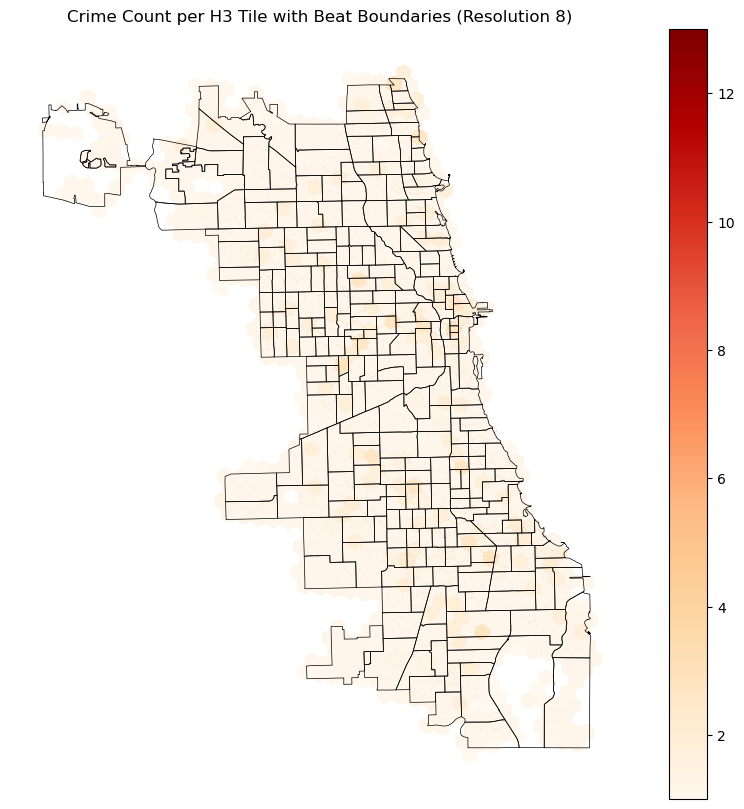

In [22]:
# Plot H3 crime intensity and overlay Chicago Beat boundaries (for visual context to understand spatial distribution of crime counts in relation to police beats)
fig, ax = plt.subplots(figsize=(10, 10))

# Base layer: H3 tiles
gdf_tiles.to_crs("EPSG:4326").plot(
    column="crime_count",
    cmap="OrRd",
    legend=True,
    ax=ax,
    alpha=0.75
)

# Overlay: beat boundaries
beats_gdf.to_crs("EPSG:4326").boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.5
)

ax.set_title(f"Crime Count per H3 Tile with Beat Boundaries (Resolution {RESOLUTION})")
ax.set_axis_off()
plt.show()

In [82]:
# Preview the shift-level master grid
print("\nSample master grid (8-hour shifts):")
preview_cols = ["h3_address", "shift_date", "shift", "crime_count", "target", "Date", "hour"]
final_df[preview_cols].head(10)


Sample master grid (8-hour shifts):


,h3_address,shift_date,shift,crime_count,target,Date,hour
0,882664cccbfffff,2021-12-31,morning_noon,0.0,0,2021-12-31 06:00:00,6
1,882664cccbfffff,2021-12-31,afternoon_night,0.0,0,2021-12-31 14:00:00,14
2,882664cccbfffff,2021-12-31,overnight,1.0,1,2021-12-31 22:00:00,0
3,882664cccbfffff,2022-01-01,morning_noon,0.0,0,2022-01-01 06:00:00,6
4,882664cccbfffff,2022-01-01,afternoon_night,0.0,0,2022-01-01 14:00:00,14
5,882664cccbfffff,2022-01-01,overnight,0.0,0,2022-01-01 22:00:00,22
6,882664cccbfffff,2022-01-02,morning_noon,0.0,0,2022-01-02 06:00:00,6
7,882664cccbfffff,2022-01-02,afternoon_night,0.0,0,2022-01-02 14:00:00,14
8,882664cccbfffff,2022-01-02,overnight,1.0,1,2022-01-02 22:00:00,3
9,882664cccbfffff,2022-01-03,morning_noon,0.0,0,2022-01-03 06:00:00,6


---
### Step 3: Feature Engineering
- **Community Area**: Neighbourhood context of the tile
- **1-Day Lag**: What happened yesterday (yesterday crime count in the same tile and shift)?
- **7-Day Rolling Average Normalised (City Avg)**: What is the recent situation in the last week? Captures short-term volatility. 
- **30-Day Rolling Average Normalised (City Avg)**: What is the long-term baseline risk for this area? Identifies sticky hotspots that persists regardless of the day.
- **Tile Crime Density Percentile**: EWMA-based crime density percentile rank of the tile on that day
- **Tile Momentum**: Ratio of short term EWMA to long term EWMA (momentum)
- **Day Sin/Cos**: Weekly patterns
- **Month Sin/Cos**: Monthly patterns
- **Afternoon_Night and Overnight Shift Flag**: Which 8 hour shift block is this? Morning_Noon is baseline. 
- **Weekend Flag**: Is this a Saturday or Sunday? Human behaviour shifts on weekends.
- **Winter Evening Flag**: More dark hours in afternoon_night shift in winter months
- **1-Day Spatial Lag (Neighbour) Normalised (City Avg)**: What happened nearby yesterday? Any spillover effect?

In [83]:
# =============================================================================
# Spatial Join: Merge community_df onto final_df (point-in-polygon)
# Assigns each H3 tile to a Chicago community area (1–77) via centroid lookup
# =============================================================================
print("Assigning community areas to H3 tiles via spatial join...")

# 1) Build community GeoDataFrame from WKT geometry stored in community_df
community_gdf = gpd.GeoDataFrame(
    community_df[['AREA_NUMBE', 'COMMUNITY']].copy(),
    geometry=gpd.GeoSeries.from_wkt(community_df['the_geom']),
    crs="EPSG:4326"
)

# 2) Get unique H3 tiles and compute their centroids as Point geometries
unique_tiles = final_df['h3_address'].unique()
lat_lngs = [h3.cell_to_latlng(tile) for tile in unique_tiles]
tiles_gdf = gpd.GeoDataFrame(
    {'h3_address': unique_tiles},
    geometry=gpd.points_from_xy(
        [lng for _, lng in lat_lngs],
        [lat for lat, _ in lat_lngs]
    ),
    crs="EPSG:4326"
)

# 3) Point-in-polygon spatial join: each tile centroid -> community polygon
tiles_joined = gpd.sjoin(
    tiles_gdf,
    community_gdf[['AREA_NUMBE', 'geometry']],
    how='left',
    predicate='within'
).drop_duplicates(subset='h3_address')

# 4) Map community_area_id back onto final_df
community_map = tiles_joined.set_index('h3_address')['AREA_NUMBE'].to_dict()
final_df['community_area_id'] = (
    final_df['h3_address']
    .map(community_map)
    .fillna(-1)
    .astype(int)
)

n_matched = (final_df['community_area_id'] != -1).sum()
print(f"   Tiles : {len(unique_tiles):,} total | {tiles_joined['AREA_NUMBE'].notna().sum():,} matched to a community area")
print(f"   Rows  : {n_matched:,} / {len(final_df):,} matched ({n_matched/len(final_df)*100:.1f}%)")
print(f"   Unique community areas assigned: {final_df['community_area_id'].nunique()}")
final_df[['h3_address', 'community_area_id']].drop_duplicates().head(10)

Assigning community areas to H3 tiles via spatial join...
   Tiles : 857 total | 765 matched to a community area
   Rows  : 3,355,290 / 3,758,802 matched (89.3%)
   Unique community areas assigned: 78


,h3_address,community_area_id
0,882664cccbfffff,46
4386,882664cd81fffff,71
8772,882664cc11fffff,69
13158,882664c1bdfffff,33
17544,882664c819fffff,26
21930,882664ca01fffff,21
26316,882664c1e7fffff,8
30702,882664c8cbfffff,29
35088,882664cdbdfffff,72
39474,882664cc4dfffff,38


In [84]:
# Ensure Date is datetime and sort within each tile
final_df['Date'] = pd.to_datetime(final_df['Date'])
final_df = final_df.sort_values(['h3_address', 'Date'])

In [85]:
# 1-Day Lag: What happened at this same shift yesterday?
# Group by tile AND shift so shift(1) compares same shift across days (true 1-day lag)
# e.g. morning_noon today <- morning_noon yesterday (not overnight 8h ago)
final_df['lag_1d'] = final_df.groupby(['h3_address', 'shift'])['crime_count'].shift(1)

# Rolling Averages: The 'Momentum' of the tile
# Group by tile AND shift so window=7 means 7 calendar days (not 7 shifts ~2.3 days)
# use shift(1) to avoid data leakage (don't include current day in the average)
final_df['rolling_7d_mean'] = (
    final_df.groupby(['h3_address', 'shift'])['crime_count']
    .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
)

final_df['rolling_30d_mean'] = (
    final_df.groupby(['h3_address', 'shift'])['crime_count']
    .transform(lambda x: x.shift(1).rolling(window=30, min_periods=1).mean())
)

In [86]:
# =============================================================================
# FEATURE: Tile Crime Density Percentile (EWMA-based, no leakage)
#
# Why EWMA over simple expanding mean:
#   - Tiles that improved recently decay toward their new baseline
#   - halflife=30 means an obs 30 days ago has half the weight of today
#
# Why rank(pct=True) per date:
#   - Normalises across cities with different absolute crime levels
#   - A tile in Chicago vs. a smaller city are comparable on [0, 1] scale
# =============================================================================

# -----------------------------------------------------------------------------
# Step 1: Build daily tile-level totals (collapse across shifts)
# -----------------------------------------------------------------------------
daily_tile = (
    final_df
    .groupby(['h3_address', 'shift_date'])['crime_count']
    .sum()
    .reset_index()
    .sort_values(['h3_address', 'shift_date'])
    .reset_index(drop=True)
)

# -----------------------------------------------------------------------------
# Step 2: EWMA per tile (shift(1) prevents same-day leakage)
# halflife=30 days -> observation 30 days ago has 50% weight of today
# -----------------------------------------------------------------------------
daily_tile['tile_ewma_crime'] = (
    daily_tile
    .groupby('h3_address')['crime_count']
    .transform(lambda x: x.shift(1).ewm(halflife=30, min_periods=1).mean())
)

# -----------------------------------------------------------------------------
# Step 3: Percentile rank within each date (city-normalised, 0.0 to 1.0)
# fillna(0.5) on day 1: unknown history -> assume median, not safest
# -----------------------------------------------------------------------------
daily_tile['tile_crime_density_percentile'] = (
    daily_tile
    .groupby('shift_date')['tile_ewma_crime']
    .transform(lambda x: x.rank(pct=True))
    .fillna(0.5)
)

# -----------------------------------------------------------------------------
# Step 4: Merge back onto final_df (shift-level rows)
# -----------------------------------------------------------------------------
final_df = final_df.merge(
    daily_tile[['h3_address', 'shift_date', 'tile_crime_density_percentile']],
    on=['h3_address', 'shift_date'],
    how='left'
)

# -----------------------------------------------------------------------------
# Sanity checks
# -----------------------------------------------------------------------------
print("=== Tile Crime Density Percentile ===\n")

print("Distribution of tile_crime_density_percentile (should be ~uniform 0-1):")
print(final_df['tile_crime_density_percentile'].describe().round(4))

print("\nTop 10 tiles by current EWMA crime rate:")
print(
    daily_tile
    .sort_values('shift_date')
    .groupby('h3_address')
    .last()
    [['tile_ewma_crime', 'tile_crime_density_percentile']]
    .sort_values('tile_ewma_crime', ascending=False)
    .head(10)
    .round(4)
)

print("\nNull counts:")
print(final_df[['tile_crime_density_percentile']].isnull().sum())

=== Tile Crime Density Percentile ===

Distribution of tile_crime_density_percentile (should be ~uniform 0-1):
count    3.758802e+06
mean     5.006000e-01
std      2.882000e-01
min      1.200000e-03
25%      2.509000e-01
50%      5.000000e-01
75%      7.503000e-01
max      1.000000e+00
Name: tile_crime_density_percentile, dtype: float64

Top 10 tiles by current EWMA crime rate:
                 tile_ewma_crime  tile_crime_density_percentile
h3_address                                                     
882664c1a9fffff           1.9715                         1.0000
882664c1e1fffff           1.7465                         0.9988
882664c1e7fffff           1.2792                         0.9977
882664cea7fffff           1.1206                         0.9965
882664ceb5fffff           1.0929                         0.9953
882664cce1fffff           1.0544                         0.9942
882664c8cbfffff           1.0531                         0.9930
882664cc01fffff           1.0052           

In [87]:
# =============================================================================
# FEATURE: Tile Momentum
# Ratio of short-term EWMA (halflife=7) to long-term EWMA (halflife=30)
# > 1.0 = tile currently running hotter than its own long-run baseline
# < 1.0 = tile currently cooling relative to its own baseline
# = 1.0 = tile running at its historical norm (also default for cold-start)
#
# Why ratio over absolute difference:
#   Absolute differences are dominated by noise for low-crime tiles
#   Ratio is scale-invariant — a quiet tile doubling activity scores the
#   same momentum as a busy tile doubling activity
# =============================================================================

EPSILON = 1e-6

daily_tile['tile_ewma_fast'] = (
    daily_tile
    .groupby('h3_address')['crime_count']
    .transform(lambda x: x.shift(1).ewm(halflife=7, min_periods=1).mean())
)

daily_tile['tile_ewma_slow'] = (
    daily_tile
    .groupby('h3_address')['crime_count']
    .transform(lambda x: x.shift(1).ewm(halflife=30, min_periods=1).mean())
)

daily_tile['tile_momentum'] = (
    daily_tile['tile_ewma_fast'] / (daily_tile['tile_ewma_slow'] + EPSILON)
).fillna(1.0)  # no history yet -> assume at baseline, not accelerating

# Merge onto final_df
final_df = final_df.drop(
    columns=['tile_momentum'],
    errors='ignore'
)

final_df = final_df.merge(
    daily_tile[['h3_address', 'shift_date', 'tile_momentum']],
    on=['h3_address', 'shift_date'],
    how='left'
)

# Sanity check
print("tile_momentum distribution:")
print(final_df['tile_momentum'].describe().round(4))
print(f"\nCorrelation with target: {final_df['tile_momentum'].corr(final_df['target']):.4f}")

# Expected output:
#   mean ~= 1.0-1.2 (slight positive skew from hotspot tiles)
#   values below 0.5 = tiles that have cooled significantly
#   values above 2.0 = tiles in an active flare-up
print("\nValue distribution check:")
print(f"   Tiles at baseline (0.8-1.2) : {final_df['tile_momentum'].between(0.8, 1.2).mean():.1%}")
print(f"   Tiles cooling     (< 0.8)   : {(final_df['tile_momentum'] < 0.8).mean():.1%}")
print(f"   Tiles accelerating(> 1.2)   : {(final_df['tile_momentum'] > 1.2).mean():.1%}")

tile_momentum distribution:
count    3.758802e+06
mean     8.147000e-01
std      5.492000e-01
min      0.000000e+00
25%      4.119000e-01
50%      8.685000e-01
75%      1.142300e+00
max      4.127500e+00
Name: tile_momentum, dtype: float64

Correlation with target: 0.0810

Value distribution check:
   Tiles at baseline (0.8-1.2) : 35.0%
   Tiles cooling     (< 0.8)   : 44.3%
   Tiles accelerating(> 1.2)   : 20.7%


In [88]:
# Cyclical time features: Encode day of week and month as sine/cosine pairs to capture cyclical patterns without introducing artificial discontinuities
# Extract basic components
final_df['day_of_week'] = final_df['Date'].dt.dayofweek
final_df['month'] = final_df['Date'].dt.month

# Sine/Cosine Transformation for Day of Week (0-6)
# Sunday (6) is adjacent to Monday (0)
final_df['day_sin'] = np.sin(2 * np.pi * final_df['day_of_week'] / 7)
final_df['day_cos'] = np.cos(2 * np.pi * final_df['day_of_week'] / 7)

# Sine/Cosine Transformation for Month (1-12)
# Subtract 1 from month to make it 0-11 for the transformation, so December (12) is adjacent to January (1)
final_df['month_sin'] = np.sin(2 * np.pi * (final_df['month']-1) / 12)
final_df['month_cos'] = np.cos(2 * np.pi * (final_df['month']-1) / 12)

# Shift identity — which 8-hour block is this?
# Two shift dummies — morning_noon is the baseline
final_df['is_afternoon_night'] = (final_df['shift'] == 'afternoon_night').astype(int)
final_df['is_overnight']       = (final_df['shift'] == 'overnight').astype(int)

In [89]:
# Weekend flag
final_df['is_weekend'] = final_df['day_of_week'].isin([5, 6]).astype(int)

In [90]:
# Simple Seasonal Darkness Proxy 
# Chicago: Winter months (Nov, Dec, Jan, Feb) have more dark hours in Shift 1 (Afternoon)
final_df['is_winter_evening'] = (
    (final_df['month'].isin([11, 12, 1, 2])) & 
    (final_df['shift'] == 'afternoon_night')
).astype(int)

In [91]:
# Spatial lag feature from neighboring H3 tiles 
import h3

def get_neighbor_stats(df):
    # 1) Build a lookup of the PREVIOUS shift's crime count for each (Date, h3_address).
    #    Sort by tile then time so shift(1) gives the immediately preceding shift.
    df_sorted = df.sort_values(['h3_address', 'Date'])
    prev_crime = (
        df_sorted
        .groupby('h3_address')['crime_count']
        .shift(1)          # previous shift's count (avoids concurrent leakage)
        .fillna(0)         # first shift of each tile has no prior -> treat as 0
    )

    # Map (current_Date, h3_address) -> previous shift's crime count
    prev_lookup = dict(zip(
        zip(df_sorted['Date'], df_sorted['h3_address']),
        prev_crime
    ))

    def calc_spatial_lag(row):
        # Find 1-ring neighbors (up to 6), excluding the tile itself
        neighbors = h3.grid_disk(row['h3_address'], k=1)
        neighbors = [n for n in neighbors if n != row['h3_address']]

        neighbor_counts = []
        for n in neighbors:
            # Look up PREVIOUS shift's crime count for neighbor n at the current Date.
            # This avoids leaking same-shift concurrent data from neighbors.
            count = prev_lookup.get((row['Date'], n), 0)
            neighbor_counts.append(count)

        return sum(neighbor_counts)

    # 2) Apply row-wise to create spatial lag feature
    # Note: this may take a few minutes on very large datasets
    df['neighbor_lag_1d'] = df.apply(calc_spatial_lag, axis=1)

    return df

final_df = get_neighbor_stats(final_df)

In [92]:
# =============================================================================
# FEATURE: City-Normalised Rolling Statistics
#
# Why normalise:
#   rolling_30d_mean, rolling_7d_mean, neighbor_lag_1d are in raw crime count
#   units. A value of 0.3 in Chicago (high-crime city) signals moderate risk,
#   while 0.3 in a smaller city may signal a genuine hotspot. Dividing by the
#   city's concurrent baseline makes these features comparable across cities.
#
# Why NOT normalise lag_1d:
#   lag_1d is a single-shift count (typically 0/1/2). Most tiles have lag_1d=0,
#   so dividing by a city mean near 0 produces unstable large values. The signal
#   is better preserved as a raw count + a binary flag (did anything happen?).
#
# Normalisation formula:
#   normalised = raw / (city_baseline + epsilon)
#   epsilon = 1e-6 prevents division by zero in low-crime periods
#
# City baseline is computed as the shift-level mean across ALL tiles for that
#   shift_date, using only past data (shift(1)) to prevent leakage.
# =============================================================================

EPSILON = 1e-6  # prevents division by zero

# -----------------------------------------------------------------------------
# Step 1: Compute city-wide baseline per shift_date
# This is the average crime count across all tiles on a given date —
# the "city temperature" that individual tile stats are measured against.
# Use shift(1) so today's city mean doesn't include today's tile counts.
# -----------------------------------------------------------------------------
city_daily_mean = (
    final_df
    .groupby('shift_date')['crime_count']
    .mean()
    .reset_index()
    .rename(columns={'crime_count': 'city_daily_mean'})
    .sort_values('shift_date')
)

# Expanding mean of the city baseline — avoids using future city-level data
# e.g. the normaliser on 2022-03-01 is the mean of all city daily means up to 2022-02-28
city_daily_mean['city_baseline'] = (
    city_daily_mean['city_daily_mean']
    .shift(1)
    .expanding()
    .mean()
)

# Fill day-1 NaN with the first available city mean (no prior history)
city_daily_mean['city_baseline'] = city_daily_mean['city_baseline'].fillna(
    city_daily_mean['city_daily_mean'].iloc[0]
)

# Merge city baseline onto final_df
final_df = final_df.merge(
    city_daily_mean[['shift_date', 'city_baseline']],
    on='shift_date',
    how='left'
)

# -----------------------------------------------------------------------------
# Step 2: Normalise rolling_30d_mean
# Captures whether this tile's long-run rate is high RELATIVE to city average
# e.g. value of 3.0 means this tile's 30d average is 3x the city baseline
# -----------------------------------------------------------------------------
final_df['rolling_30d_mean_norm'] = (
    final_df['rolling_30d_mean'] / (final_df['city_baseline'] + EPSILON)
)

# -----------------------------------------------------------------------------
# Step 3: Normalise rolling_7d_mean
# Short-term momentum relative to what the whole city is experiencing right now
# e.g. value of 2.0 means this tile's recent week is twice the city pace
# -----------------------------------------------------------------------------
final_df['rolling_7d_mean_norm'] = (
    final_df['rolling_7d_mean'] / (final_df['city_baseline'] + EPSILON)
)

# -----------------------------------------------------------------------------
# Step 4: Normalise neighbor_lag_1d
# Spillover pressure from neighbours, scaled to city context
# -----------------------------------------------------------------------------
final_df['neighbor_lag_1d_norm'] = (
    final_df['neighbor_lag_1d'] / (final_df['city_baseline'] + EPSILON)
)

# -----------------------------------------------------------------------------
# Step 5: lag_1d — keep raw, add binary flag instead of normalising
# is_crime_yesterday = 1 if any crime occurred in this tile last shift
# This preserves the sharp binary signal (something happened / nothing happened)
# without the instability of dividing near-zero counts by a near-zero baseline
# -----------------------------------------------------------------------------
final_df['is_crime_yesterday'] = (final_df['lag_1d'] > 0).astype(int)

# -----------------------------------------------------------------------------
# Sanity checks
# -----------------------------------------------------------------------------
print("=== City-Normalised Rolling Features ===\n")

print("city_baseline stats (should be a small positive number, stable over time):")
print(city_daily_mean['city_baseline'].describe().round(6))

print("\nrolling_30d_mean_norm (values >> 1.0 = persistent hotspot tiles):")
print(final_df['rolling_30d_mean_norm'].describe().round(4))

print("\nrolling_7d_mean_norm (values >> 1.0 = recently active tiles):")
print(final_df['rolling_7d_mean_norm'].describe().round(4))

print("\nneighbor_lag_1d_norm:")
print(final_df['neighbor_lag_1d_norm'].describe().round(4))

print("\nis_crime_yesterday value counts:")
print(final_df['is_crime_yesterday'].value_counts())

print("\nNull check:")
print(final_df[['rolling_30d_mean_norm', 'rolling_7d_mean_norm',
                'neighbor_lag_1d_norm', 'is_crime_yesterday']].isnull().sum())

=== City-Normalised Rolling Features ===

city_baseline stats (should be a small positive number, stable over time):
count    1462.000000
mean        0.076213
std         0.005551
min         0.042007
25%         0.074953
50%         0.078639
75%         0.079467
max         0.080698
Name: city_baseline, dtype: float64

rolling_30d_mean_norm (values >> 1.0 = persistent hotspot tiles):
count    3.756231e+06
mean     1.034600e+00
std      1.383100e+00
min      0.000000e+00
25%      0.000000e+00
50%      4.464000e-01
75%      1.652400e+00
max      9.522000e+01
Name: rolling_30d_mean_norm, dtype: float64

rolling_7d_mean_norm (values >> 1.0 = recently active tiles):
count    3.756231e+06
mean     1.036500e+00
std      1.868700e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.809000e+00
max      9.522000e+01
Name: rolling_7d_mean_norm, dtype: float64

neighbor_lag_1d_norm:
count    3.758802e+06
mean     6.092100e+00
std      1.076340e+01
min      0.000000e+00

In [93]:
# Drop any NaNs created by the shift (usually the first few rows of each tile)
final_df = final_df.dropna()

In [94]:
# Preview engineered features except Community Area ID, Weekend flag (categorical flag is less interesting in a describe() summary)
feature_cols = [col for col in final_df.columns if col != 'community_area_id' and col != 'is_weekend']
print("\n--- Engineered Features Preview ---")
final_df[feature_cols].describe().round(2)


--- Engineered Features Preview ---


,shift_date,crime_count,target,Date,hour,lag_1d,rolling_7d_mean,rolling_30d_mean,tile_crime_density_percentile,tile_momentum,...,month_cos,is_afternoon_night,is_overnight,is_winter_evening,neighbor_lag_1d,city_baseline,rolling_30d_mean_norm,rolling_7d_mean_norm,neighbor_lag_1d_norm,is_crime_yesterday
count,3756231,3756231.00,3756231.00,3756231,3756231.00,3756231.00,3756231.00,3756231.00,3756231.00,3756231.00,...,3756231.00,3756231.00,3756231.00,3756231.00,3756231.00,3756231.00,3756231.00,3756231.00,3756231.00,3756231.00
mean,2023-12-31 23:59:59.999999744,0.08,0.07,2024-01-01 14:00:00.000001536,13.91,0.08,0.08,0.08,0.50,0.81,...,-0.00,0.33,0.33,0.11,0.46,0.08,1.03,1.04,6.10,0.07
min,2022-01-01 00:00:00,0.00,0.00,2022-01-01 06:00:00,0.00,0.00,0.00,0.00,0.00,0.00,...,-1.00,0.00,0.00,0.00,0.00,0.04,0.00,0.00,0.00,0.00
25%,2023-01-01 00:00:00,0.00,0.00,2023-01-01 06:00:00,6.00,0.00,0.00,0.00,0.25,0.41,...,-0.87,0.00,0.00,0.00,0.00,0.07,0.00,0.00,0.00,0.00
50%,2024-01-01 00:00:00,0.00,0.00,2024-01-01 14:00:00,14.00,0.00,0.00,0.03,0.50,0.87,...,-0.00,0.00,0.00,0.00,0.00,0.08,0.45,0.00,0.00,0.00
75%,2024-12-31 00:00:00,0.00,0.00,2024-12-31 22:00:00,22.00,0.00,0.14,0.10,0.75,1.14,...,0.50,1.00,1.00,0.00,1.00,0.08,1.65,1.81,12.61,0.00
max,2025-12-31 00:00:00,13.00,1.00,2025-12-31 22:00:00,23.00,13.00,4.00,4.00,1.00,4.13,...,1.00,1.00,1.00,1.00,22.00,0.08,95.22,95.22,293.05,1.00
std,NaN,0.30,0.26,NaN,6.59,0.30,0.14,0.10,0.29,0.55,...,0.71,0.47,0.47,0.31,0.82,0.01,1.38,1.87,10.77,0.26


In [95]:
final_df[final_df['crime_count'] > 1.0].head(5)

,h3_address,shift_date,shift,crime_count,target,Date,hour,community_area_id,lag_1d,rolling_7d_mean,...,is_afternoon_night,is_overnight,is_weekend,is_winter_evening,neighbor_lag_1d,city_baseline,rolling_30d_mean_norm,rolling_7d_mean_norm,neighbor_lag_1d_norm,is_crime_yesterday
22436,8826641913fffff,2022-06-17,overnight,2.0,1,2022-06-17 22:00:00,23,55,0.0,0.0,...,0,1,0,0,0.0,0.071190,0.468223,0.0,0.0,0
23620,8826641913fffff,2023-07-17,afternoon_night,2.0,1,2023-07-17 14:00:00,17,55,0.0,0.0,...,1,0,0,0,0.0,0.076466,0.435916,0.0,0.0,0
24861,8826641913fffff,2024-09-03,morning_noon,2.0,1,2024-09-03 06:00:00,6,55,0.0,0.0,...,0,0,0,0,0.0,0.080198,0.000000,0.0,0.0,0
25252,8826641913fffff,2025-01-11,afternoon_night,2.0,1,2025-01-11 14:00:00,20,55,0.0,0.0,...,1,0,1,1,0.0,0.080231,0.000000,0.0,0.0,0
25999,8826641913fffff,2025-09-17,afternoon_night,2.0,1,2025-09-17 14:00:00,18,55,0.0,0.0,...,1,0,0,0,0.0,0.079535,0.000000,0.0,0.0,0


In [96]:
final_df.columns

Index(['h3_address', 'shift_date', 'shift', 'crime_count', 'target', 'Date',
       'hour', 'community_area_id', 'lag_1d', 'rolling_7d_mean',
       'rolling_30d_mean', 'tile_crime_density_percentile', 'tile_momentum',
       'day_of_week', 'month', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'is_afternoon_night', 'is_overnight', 'is_weekend', 'is_winter_evening',
       'neighbor_lag_1d', 'city_baseline', 'rolling_30d_mean_norm',
       'rolling_7d_mean_norm', 'neighbor_lag_1d_norm', 'is_crime_yesterday'],
      dtype='object')

---
### Step 3.5: Correlation Analysis and LInearity Checks

- Identify relationships between features and target
- Detect **possible multicollinearity** (highly correlated features can cause issues in logistic regression)
- Guide feature selection decisions

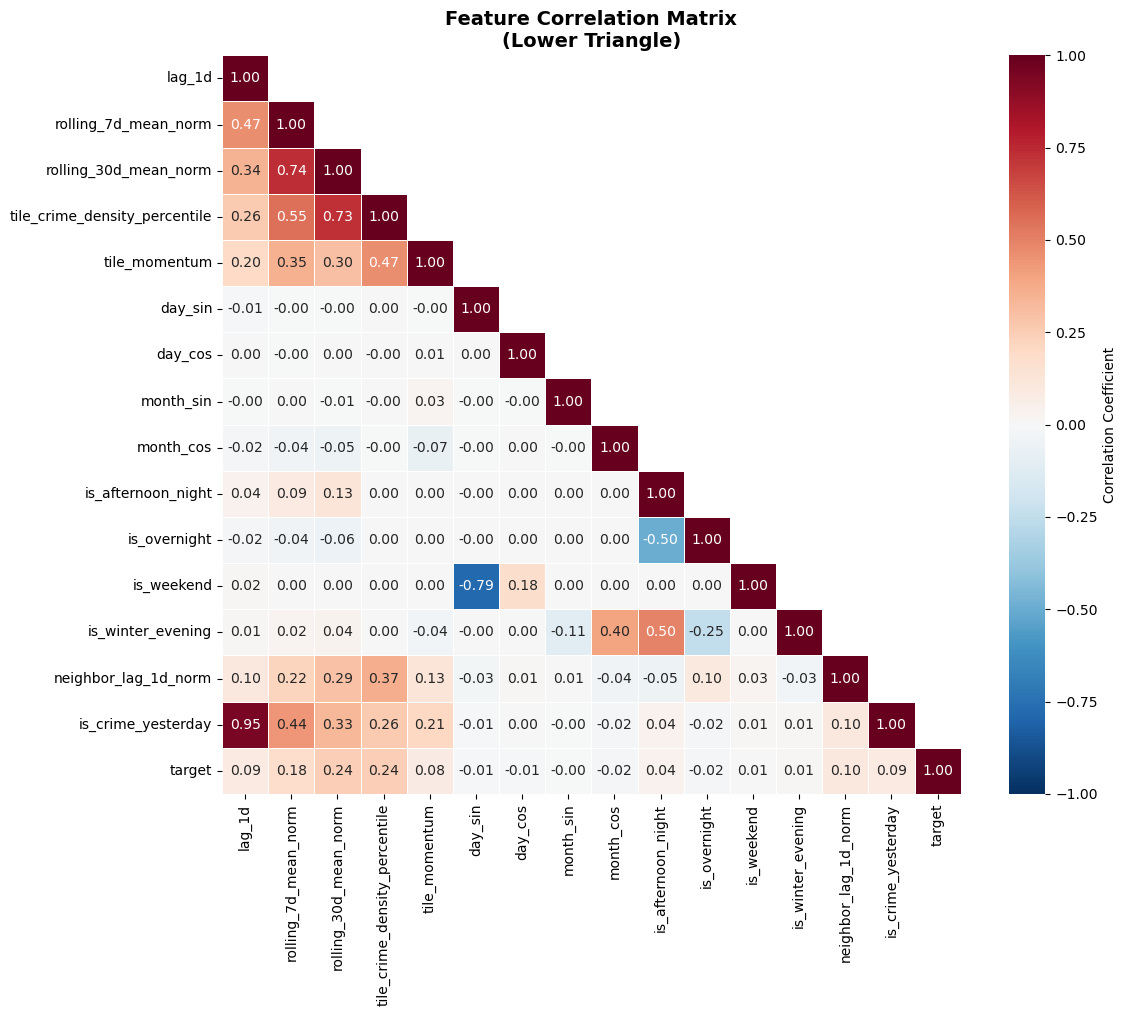

CORRELATION ANALYSIS INSIGHTS

[ANALYSIS] Correlations with Target (Crime in Tile x Date x Shift):
----------------------------------------
  tile_crime_density_percentile: +0.243 (Moderate ^)
  rolling_30d_mean_norm: +0.243 (Moderate ^)
  rolling_7d_mean_norm: +0.182 (Moderate ^)
  neighbor_lag_1d_norm: +0.104 (Weak ^)
  lag_1d              : +0.090 (Weak ^)
  is_crime_yesterday  : +0.088 (Weak ^)
  tile_momentum       : +0.081 (Weak ^)
  is_afternoon_night  : +0.044 (Weak ^)
  is_overnight        : -0.023 (Weak v)
  month_cos           : -0.022 (Weak v)
  day_sin             : -0.011 (Weak v)
  is_winter_evening   : +0.011 (Weak ^)
  day_cos             : -0.008 (Weak v)
  is_weekend          : +0.007 (Weak ^)
  month_sin           : -0.002 (Weak v)

[!]  Potential Multicollinearity Issues:
----------------------------------------
  lag_1d <-> is_crime_yesterday: 0.946
  rolling_7d_mean_norm <-> rolling_30d_mean_norm: 0.741
  rolling_30d_mean_norm <-> tile_crime_density_percentile: 0

In [97]:
# =============================================================================
# CORRELATION HEATMAP
# =============================================================================
# Pearson correlation measures linear relationships between numeric/binary variables
# Values range from -1 (perfect negative) to +1 (perfect positive)

# Select numeric/binary columns for correlation analysis (excluding community_area_id)
numeric_cols = ['lag_1d', 'rolling_7d_mean_norm', 'rolling_30d_mean_norm',
                'tile_crime_density_percentile', 'tile_momentum',
                'day_sin', 'day_cos', 'month_sin', 'month_cos',
                'is_afternoon_night', 'is_overnight',
                'is_weekend', 'is_winter_evening',
                'neighbor_lag_1d_norm','is_crime_yesterday','target']

# Calculate correlation matrix
correlation_matrix = final_df[numeric_cols].corr()

# Create heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)  # Hide upper triangle

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('Feature Correlation Matrix\n(Lower Triangle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print correlation insights
print("=" * 60)
print("CORRELATION ANALYSIS INSIGHTS")
print("=" * 60)

# Get correlations with target
target_corr = correlation_matrix['target'].drop('target').sort_values(key=abs, ascending=False)

print("\n[ANALYSIS] Correlations with Target (Crime in Tile x Date x Shift):")
print("-" * 40)
for feature, corr in target_corr.items():
    direction = "^" if corr > 0 else "v"
    strength = "Strong" if abs(corr) > 0.5 else "Moderate" if abs(corr) > 0.15 else "Weak"
    print(f"  {feature:20s}: {corr:+.3f} ({strength} {direction})")

# Check for multicollinearity
print("\n[!]  Potential Multicollinearity Issues:")
print("-" * 40)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    for f1, f2, corr in high_corr_pairs:
        print(f"  {f1} <-> {f2}: {corr:.3f}")
    print("\n  -> Consider removing one feature from each highly correlated pair")
else:
    print("  No severe multicollinearity detected (all |r| < 0.7)")

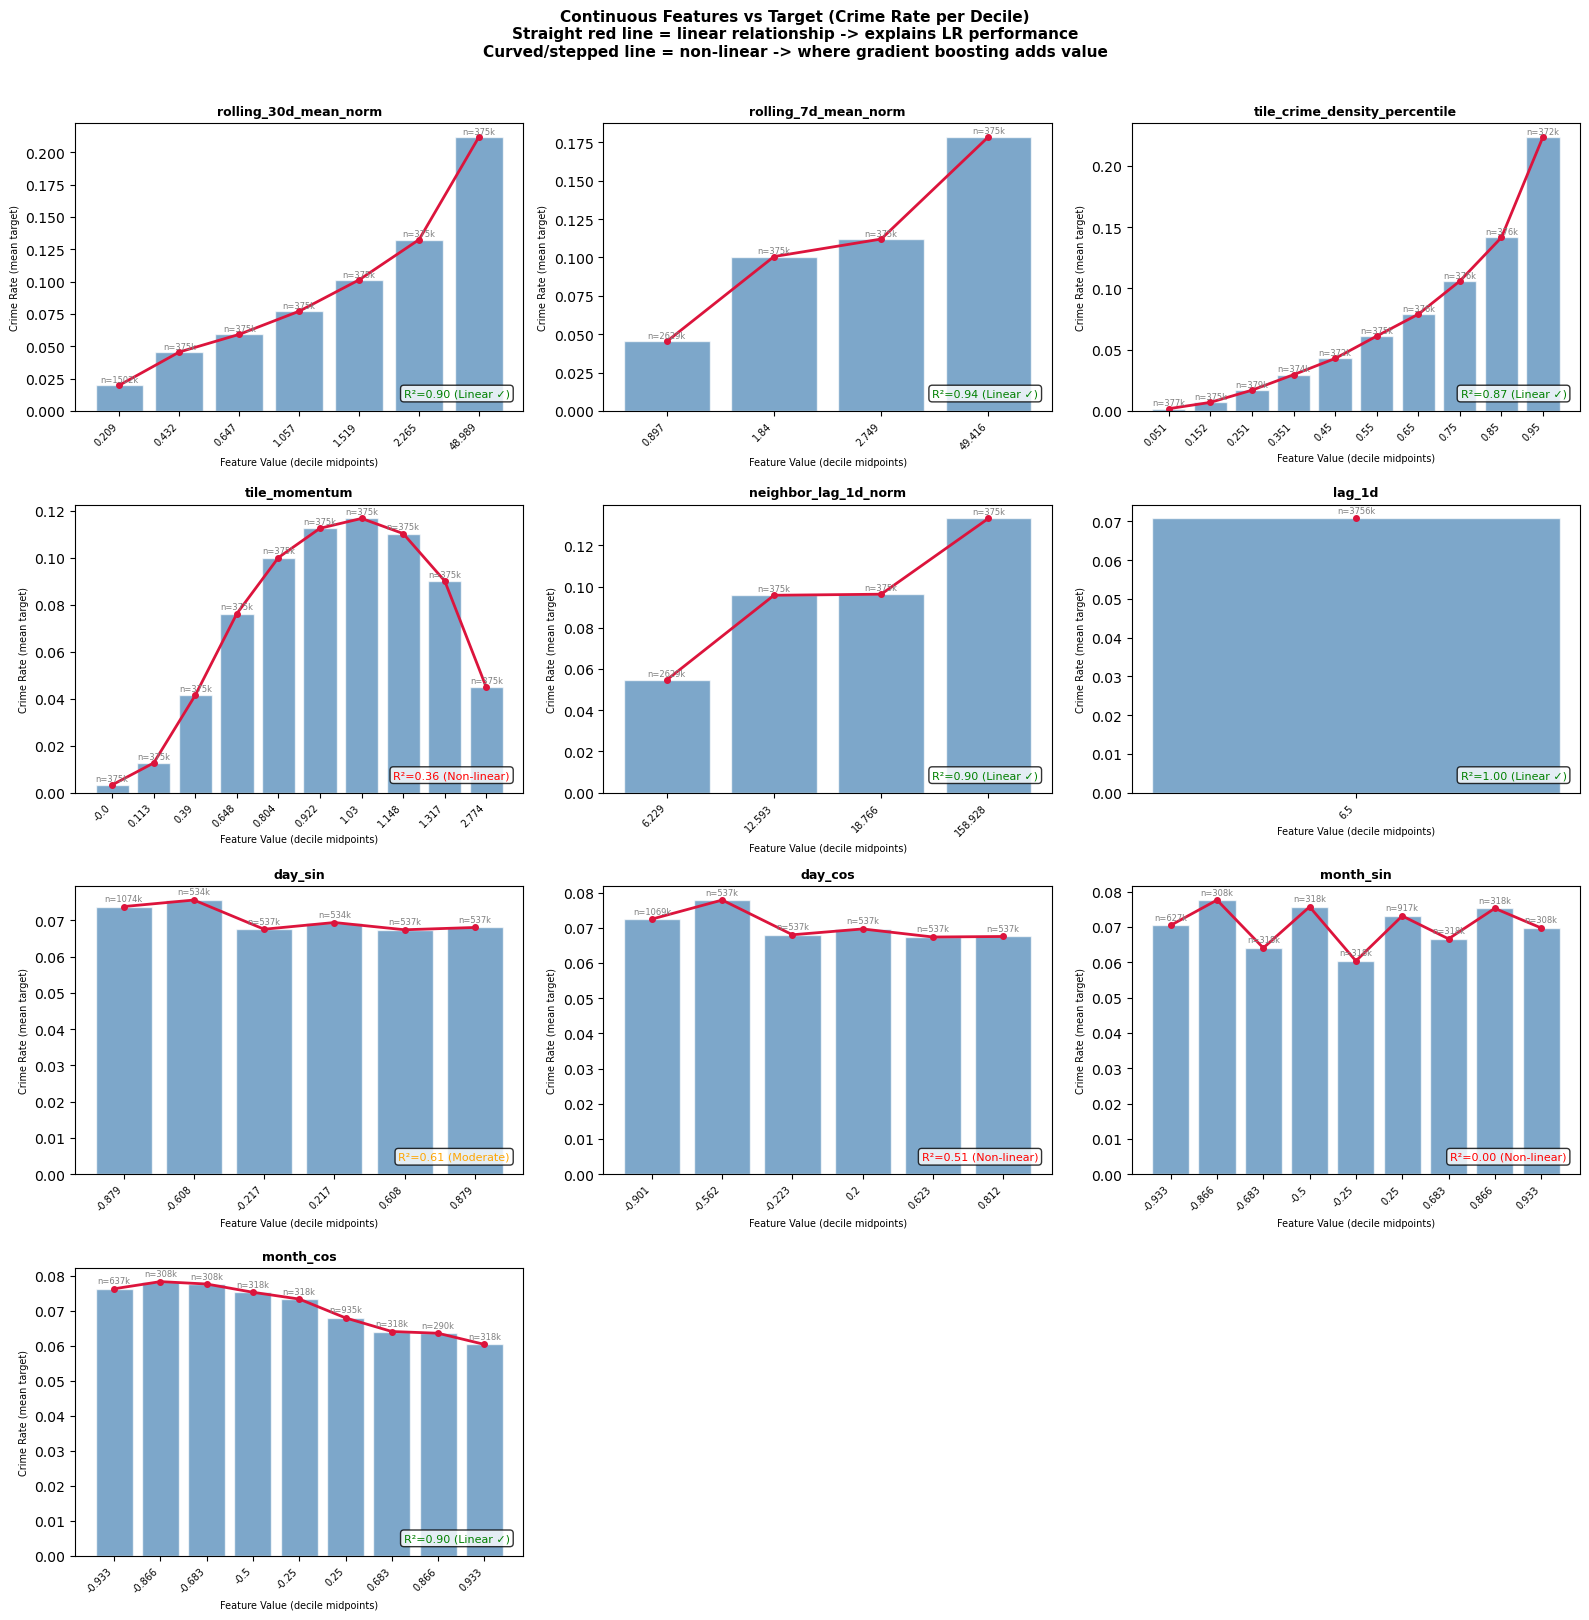

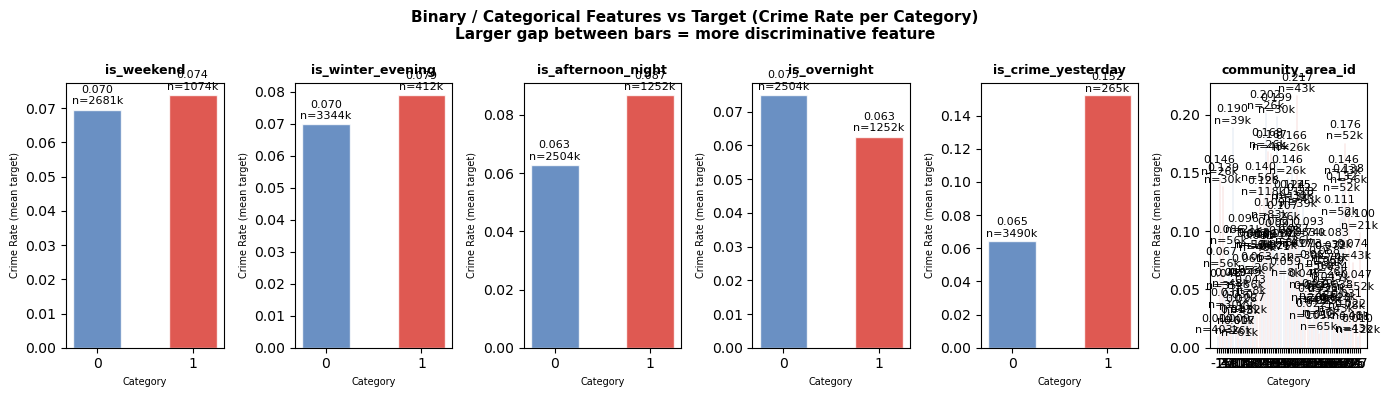


LINEARITY SUMMARY — R² of binned mean target vs feature
Feature                         Correlation   Linearity R² Interpretation
--------------------------------------------------------------------------------
rolling_30d_mean_norm               +0.2427          0.905   Linear ✓ — LR captures fully
rolling_7d_mean_norm                +0.1820          0.942   Linear ✓ — LR captures fully
tile_crime_density_percentile       +0.2432          0.868   Linear ✓ — LR captures fully
tile_momentum                       +0.0810          0.364   Non-linear — GB has advantage
neighbor_lag_1d_norm                +0.1038          0.903   Linear ✓ — LR captures fully
lag_1d                              +0.0901          1.000   Linear ✓ — LR captures fully
day_sin                             -0.0111          0.610   Moderate — LR captures mostly
day_cos                             -0.0080          0.508   Non-linear — GB has advantage
month_sin                           -0.0024          0.004   Non-

In [125]:
# =============================================================================
# FEATURE vs TARGET RELATIONSHIP VISUALISATION
#
# Purpose: Understand whether features have LINEAR or NON-LINEAR relationships
#          with the target — which directly explains why logistic regression
#          performs comparably to gradient boosting models
#
# Method per feature type:
#   Continuous features -> bin into deciles, plot mean target rate per bin
#                         A straight diagonal = linear relationship
#                         A curve/step = non-linear, gradient boosting advantage
#   Binary/categorical  -> bar chart of target rate per category
# =============================================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -----------------------------------------------------------------------------
# Helper: Mean target rate per decile bin (for continuous features)
# Binning into deciles rather than equal-width bins ensures each bin
# has roughly equal sample size — avoids misleading sparsity at extremes
# -----------------------------------------------------------------------------
def plot_continuous_vs_target(ax, df, feature, target='target', n_bins=10):
    temp = df[[feature, target]].dropna().copy()

    # If feature has <2 unique values, show a simple single bar and exit safely
    if temp[feature].nunique() < 2:
        rate = temp[target].mean() if len(temp) else 0.0
        ax.bar([0], [rate], color='steelblue', alpha=0.7, edgecolor='white')
        ax.set_xticks([0])
        ax.set_xticklabels([str(temp[feature].iloc[0]) if len(temp) else 'NA'], rotation=0, fontsize=7)
        ax.set_title(f'{feature}', fontweight='bold', fontsize=9)
        ax.set_ylabel('Crime Rate (mean target)', fontsize=7)
        ax.set_xlabel('Feature Value', fontsize=7)
        ax.annotate('R²=1.00 (Constant)',
                    xy=(0.97, 0.05), xycoords='axes fraction',
                    ha='right', fontsize=8, color='gray',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        return

    # Bin into deciles
    temp['bin'] = pd.qcut(temp[feature], q=n_bins, duplicates='drop')
    grouped = temp.groupby('bin', observed=True)[target].agg(['mean', 'count'])

    # Guard against empty grouped result
    if grouped.empty:
        ax.text(0.5, 0.5, 'No valid bins', ha='center', va='center', fontsize=9)
        ax.set_axis_off()
        return

    bin_labels = [str(b.mid.round(3)) for b in grouped.index]
    target_rates = grouped['mean'].values
    counts = grouped['count'].values

    # Bar plot of target rate per bin
    bars = ax.bar(range(len(target_rates)), target_rates,
                  color='steelblue', alpha=0.7, edgecolor='white')

    # Overlay trend line
    ax.plot(range(len(target_rates)), target_rates,
            color='crimson', linewidth=2, marker='o', markersize=4)

    # Add sample size annotations on bars
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'n={count//1000}k', ha='center', va='bottom',
                fontsize=6, color='gray')

    ax.set_xticks(range(len(bin_labels)))
    ax.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=7)
    ax.set_title(f'{feature}', fontweight='bold', fontsize=9)
    ax.set_ylabel('Crime Rate (mean target)', fontsize=7)
    ax.set_xlabel('Feature Value (decile midpoints)', fontsize=7)

    # Compute R² of linear fit robustly
    x = np.arange(len(target_rates), dtype=float)
    y = np.asarray(target_rates, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)

    if valid.sum() > 1:
        try:
            slope, intercept = np.polyfit(x[valid], y[valid], 1)
            fitted = slope * x[valid] + intercept
            ss_res = np.sum((y[valid] - fitted) ** 2)
            ss_tot = np.sum((y[valid] - y[valid].mean()) ** 2)
            r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 1.0
        except np.linalg.LinAlgError:
            r2 = np.nan
    else:
        r2 = 1.0

    if np.isfinite(r2):
        linearity = 'Linear ✓' if r2 > 0.85 else 'Moderate' if r2 > 0.60 else 'Non-linear'
        color = 'green' if r2 > 0.85 else 'orange' if r2 > 0.60 else 'red'
        label = f'R²={r2:.2f} ({linearity})'
    else:
        label = 'R²=NA (insufficient/unstable)'
        color = 'gray'

    ax.annotate(label,
                xy=(0.97, 0.05), xycoords='axes fraction',
                ha='right', fontsize=8, color=color,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))


def plot_binary_vs_target(ax, df, feature, target='target'):
    grouped = df.groupby(feature)[target].agg(['mean', 'count'])
    categories = [str(c) for c in grouped.index]
    target_rates = grouped['mean'].values
    counts = grouped['count'].values

    bars = ax.bar(categories, target_rates,
                  color=['#4575b4', '#d73027'][:len(categories)],
                  alpha=0.8, edgecolor='white', width=0.5)

    for bar, count, rate in zip(bars, counts, target_rates):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                f'{rate:.3f}\nn={count//1000}k',
                ha='center', va='bottom', fontsize=8)

    ax.set_title(f'{feature}', fontweight='bold', fontsize=9)
    ax.set_ylabel('Crime Rate (mean target)', fontsize=7)
    ax.set_xlabel('Category', fontsize=7)


# -----------------------------------------------------------------------------
# Panel 1: Continuous Features
# -----------------------------------------------------------------------------
continuous_features = [
    'rolling_30d_mean_norm',
    'rolling_7d_mean_norm',
    'tile_crime_density_percentile',
    'tile_momentum',
    'neighbor_lag_1d_norm',
    'lag_1d',
    'day_sin',
    'day_cos',
    'month_sin',
    'month_cos',
]

n_cols = 3
n_rows = int(np.ceil(len(continuous_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, feature in enumerate(continuous_features):
    if feature in final_df.columns:
        plot_continuous_vs_target(axes[i], final_df, feature)
    else:
        axes[i].set_visible(False)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    'Continuous Features vs Target (Crime Rate per Decile)\n'
    'Straight red line = linear relationship -> explains LR performance\n'
    'Curved/stepped line = non-linear -> where gradient boosting adds value',
    fontsize=11, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# Panel 2: Binary / Categorical Features
# -----------------------------------------------------------------------------
binary_features = [
    'is_weekend',
    'is_winter_evening',
    'is_afternoon_night',
    'is_overnight',
    'is_crime_yesterday',
    'community_area_id'  # Categorical with many levels, but still worth a quick look
]

fig, axes = plt.subplots(1, len(binary_features), figsize=(14, 4))

for i, feature in enumerate(binary_features):
    if feature in final_df.columns:
        plot_binary_vs_target(axes[i], final_df, feature)
    else:
        axes[i].set_visible(False)

fig.suptitle(
    'Binary / Categorical Features vs Target (Crime Rate per Category)\n'
    'Larger gap between bars = more discriminative feature',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# Panel 3: Summary Table — R² of linear fit per feature
# -----------------------------------------------------------------------------
print("\n" + "=" * 60)
print("LINEARITY SUMMARY — R² of binned mean target vs feature")
print("=" * 60)
print(f"{'Feature':<30} {'Correlation':>12} {'Linearity R²':>14} {'Interpretation'}")
print("-" * 80)

results = []
for feature in continuous_features:
    if feature not in final_df.columns:
        continue

    temp = final_df[[feature, 'target']].dropna()
    corr = temp[feature].corr(temp['target'])

    temp['bin'] = pd.qcut(temp[feature], q=10, duplicates='drop')
    grouped = temp.groupby('bin', observed=True)['target'].mean()
    x = np.arange(len(grouped), dtype=float)
    y = grouped.values.astype(float)
    valid = np.isfinite(x) & np.isfinite(y)

    if valid.sum() > 1:
        try:
            slope, intercept = np.polyfit(x[valid], y[valid], 1)
            fitted = slope * x[valid] + intercept
            ss_res = np.sum((y[valid] - fitted) ** 2)
            ss_tot = np.sum((y[valid] - y[valid].mean()) ** 2)
            r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 1.0
        except np.linalg.LinAlgError:
            r2 = np.nan
    else:
        r2 = 1.0

    interpretation = (
        "Linear ✓ — LR captures fully" if np.isfinite(r2) and r2 > 0.85 else
        "Moderate — LR captures mostly" if np.isfinite(r2) and r2 > 0.60 else
        "Non-linear — GB has advantage" if np.isfinite(r2) else
        "Unstable fit — inspect feature bins"
    )
    results.append((feature, corr, r2, interpretation))
    r2_txt = f"{r2:>14.3f}" if np.isfinite(r2) else f"{'NA':>14}"
    print(f"{feature:<30} {corr:>+12.4f} {r2_txt}   {interpretation}")

print("\nConclusion:")
linear_count = sum(1 for _, _, r2, _ in results if np.isfinite(r2) and r2 > 0.85)
nonlinear_count = sum(1 for _, _, r2, _ in results if np.isfinite(r2) and r2 <= 0.60)
print(f"   {linear_count}/{len(results)} features are linear with target")
print(f"   {nonlinear_count}/{len(results)} features are non-linear")

**Conclusion**: 
- Remove Chicago specific features, specifically community_area_id and is_winter_evening in order to build a generalisable model for other cities in U.S.. 
- Remove is_weekend as it is redundant with day_sin/cos. 
- Remove is_crime_yesterday (binary) as it is redundant too with lag_1d (continuous, more informative) 
- Understanding linearity to assess Logistic Regression as baseline vs. tree models

---
### Step 4: Prepare Training Data

In [126]:
print("="*60)
print("STEP 4: PREPARE TRAINING DATA WITH PIPELINE")
print("="*60)

# =============================================================================
# DEFINE FEATURE COLUMNS
# Separating categorical vs numeric is important for ColumnTransformer
# =============================================================================
CATEGORICAL_COLS = ['is_afternoon_night','is_overnight']  # Will be ordinally encoded
NUMERIC_COLS = [
    'lag_1d',               # 1-day lag of crime count
    'rolling_7d_mean_norm',      # 7-day rolling average of crime count normalized to city baseline
    'rolling_30d_mean_norm',     # 30-day rolling average of crime count normalized to city baseline
    'tile_crime_density_percentile',  # EWMA-based crime density percentile rank of the tile on that day
    'tile_momentum',         # Ratio of short-term EWMA to long-term EWMA (momentum)
    'day_sin',              # day of week encoded as sine
    'day_cos',              # day of week encoded as cosine
    'month_sin',            # month encoded as sine
    'month_cos',            # month encoded as cosine
    'neighbor_lag_1d_norm'  # 1-day lag of neighboring tiles' crime count normalized to city baseline
]
FEATURE_COLS = CATEGORICAL_COLS + NUMERIC_COLS
LABEL_COL = 'target'

print(f"\nFeature columns ({len(FEATURE_COLS)} total):")
print(f"   Categorical: {CATEGORICAL_COLS}")
print(f"   Numeric: {NUMERIC_COLS}")

# Drop rows with missing values
df = final_df.dropna(subset=FEATURE_COLS + [LABEL_COL]).copy()
print(f"\n   Samples after dropping NaN: {len(df):,}")

STEP 4: PREPARE TRAINING DATA WITH PIPELINE

Feature columns (12 total):
   Categorical: ['is_afternoon_night', 'is_overnight']
   Numeric: ['lag_1d', 'rolling_7d_mean_norm', 'rolling_30d_mean_norm', 'tile_crime_density_percentile', 'tile_momentum', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'neighbor_lag_1d_norm']

   Samples after dropping NaN: 3,756,231


In [127]:
# =============================================================================
# CREATE PREPROCESSING PIPELINE (ColumnTransformer)
# =============================================================================
# ColumnTransformer applies different transformations to different column types:
# - Categorical columns: OrdinalEncoder (converts strings to integers)
# - Numeric columns: 'passthrough' (no transformation needed)
#
# WHY THIS MATTERS:
# - Prevents data leakage: encoder is fit ONLY on training data
# - Ensures consistency: same encoding applied during inference
# - Clean deployment: single pipeline object to save/load

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
         CATEGORICAL_COLS),  # Encode 'category' column
        ('num', 'passthrough', NUMERIC_COLS)  # Keep numeric columns as-is
    ],
    remainder='drop'  # Drop any columns not specified
)

print("Preprocessor created:")
print("   ColumnTransformer with:")
print("   - OrdinalEncoder for categorical columns")
print("   - Passthrough for numeric columns")
print("\n   Note: Preprocessor will be fit inside the Pipeline (after train/test split)")

Preprocessor created:
   ColumnTransformer with:
   - OrdinalEncoder for categorical columns
   - Passthrough for numeric columns

   Note: Preprocessor will be fit inside the Pipeline (after train/test split)


In [128]:
# =============================================================================
# TRAIN-TEST SPLIT BY YEAR (time-aware split to avoid temporal leakage)
# =============================================================================
# Train: 2022-2024, Test: 2025

# Ensure Date column is datetime for year filtering
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Build year-based masks
train_years = [2022, 2023, 2024]
test_year = 2025

train_mask = df['Date'].dt.year.isin(train_years)
test_mask = df['Date'].dt.year.eq(test_year)

# Prepare X (raw features - NOT encoded yet) and y (target)
X_train = df.loc[train_mask, FEATURE_COLS]
y_train = df.loc[train_mask, LABEL_COL]

X_test = df.loc[test_mask, FEATURE_COLS]
y_test = df.loc[test_mask, LABEL_COL]

if len(X_train) == 0 or len(X_test) == 0:
    raise ValueError(
        f"Empty split detected. Train rows: {len(X_train)}, Test rows: {len(X_test)}. "
        "Check year filters and upstream preprocessing."
    )

print("\nData split complete (time-based, BEFORE preprocessing):")
print(f"   Training years: {train_years}")
print(f"   Test year: {test_year}")
print(f"   Training: {len(X_train):,} samples ({y_train.mean()*100:.2f}% positive)")
print(f"   Test:     {len(X_test):,} samples ({y_test.mean()*100:.2f}% positive)")
print("\n   Note: X contains raw features - preprocessing happens inside Pipeline")


Data split complete (time-based, BEFORE preprocessing):
   Training years: [2022, 2023, 2024]
   Test year: 2025
   Training: 2,817,816 samples (7.20% positive)
   Test:     938,415 samples (6.69% positive)

   Note: X contains raw features - preprocessing happens inside Pipeline


In [129]:
# =============================================================================
# SORT TRAINING DATA CHRONOLOGICALLY FOR TimeSeriesSplit
# =============================================================================
# df was sorted by ['h3_address', 'Date'] so rows are interleaved by tile, not
# purely chronological. TimeSeriesSplit requires rows ordered by time so that
# each fold's validation set is strictly AFTER its training set.
# =============================================================================
from sklearn.model_selection import TimeSeriesSplit

# Get dates for training rows and sort chronologically
train_dates = df.loc[train_mask, 'Date'].sort_values()

# Re-index X_train and y_train to match the sorted order
X_train = X_train.loc[train_dates.index]
y_train = y_train.loc[train_dates.index]

# Define TimeSeriesSplit (shared by tuning in Step 5.5)
N_SPLITS = 3
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

# Show fold structure so we can verify temporal integrity
print(f"TimeSeriesSplit(n_splits={N_SPLITS}) on training data ({len(X_train):,} rows)\n")
header = f"{'Fold':<5}  {'Train rows':>11}  {'Train period':<25}  {'Val rows':>9}  {'Val period':<25}"
print(header)
print("-" * len(header))

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    tr_dates  = train_dates.iloc[tr_idx]
    val_dates = train_dates.iloc[val_idx]
    tr_range  = f"{tr_dates.min().date()} → {tr_dates.max().date()}"
    val_range = f"{val_dates.min().date()} → {val_dates.max().date()}"
    print(f"{fold:<5}  {len(tr_idx):>11,}  {tr_range:<25}  {len(val_idx):>9,}  {val_range:<25}")

TimeSeriesSplit(n_splits=3) on training data (2,817,816 rows)

Fold    Train rows  Train period                Val rows  Val period               
-----------------------------------------------------------------------------------
1          704,454  2022-01-01 → 2022-10-01      704,454  2022-10-02 → 2023-07-02  
2        1,408,908  2022-01-01 → 2023-07-02      704,454  2023-07-03 → 2024-04-01  
3        2,113,362  2022-01-01 → 2024-04-01      704,454  2024-04-02 → 2024-12-31  


---
### Step 5: Train Models with Pipelines

We create **complete pipelines** that include:
1. **Preprocessor** (ColumnTransformer) - handles categorical encoding
2. **Model** (Logistic Regression as Baseline, XGBoost, Random Forest, LightGBM)

In [130]:
from sklearn.model_selection import cross_val_score

print("="*60)
print("STEP 5: TRAIN MODELS")
print("="*60)

# Calculate class weight for imbalanced data
# This tells the model: "zero samples are X times more important"
# Aim: to give the minority class more "weight" without losing data, instead of downsampling or SMOTE.
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nClass imbalance: {scale_pos_weight:.1f}:1 (no crime:crime)")
print(f"   Using class weighting to handle imbalance")

# Create a chronologically-ordered subsample for cross-validation
# Running cross_val_score on 2.8M rows is very slow; 300K rows (10%) gives a stable CV estimate
CV_SAMPLE_N = 300_000
cv_idx = (
    pd.Series(range(len(X_train)))
    .sample(n=min(CV_SAMPLE_N, len(X_train)), random_state=0)
    .sort_values()   # preserve time order so TimeSeriesSplit folds are valid
    .values
)
X_cv = X_train.iloc[cv_idx]
y_cv = y_train.iloc[cv_idx]

print(f"\nCV subsample   : {len(X_cv):,} rows (time-ordered, for cross_val_score)")
print(f"CV strategy    : TimeSeriesSplit(n_splits={N_SPLITS})")
print(f"Scoring metric : roc_auc") # bcause of class imbalance, AUC is more informative than accuracy

STEP 5: TRAIN MODELS

Class imbalance: 12.9:1 (no crime:crime)
   Using class weighting to handle imbalance

CV subsample   : 300,000 rows (time-ordered, for cross_val_score)
CV strategy    : TimeSeriesSplit(n_splits=3)
Scoring metric : roc_auc


In [131]:
# =========================================================================
# BASELINE PIPELINE: Preprocessor + Logistics Regression 
# =========================================================================
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

import time

print("\n" + "-"*40)
print("Training Logistic Regression Pipeline...")
print("-"*40)

# Logistic regression baseline pipeline (requires feature scaling)
lr_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        class_weight='balanced', # using balanced so model does not ignore minority class
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    ))
])

# 1. Cross-validation on time-ordered subsample (each fold gets its own preprocessor fit)
print("\n   Running cross-validation...")
cv_scores = cross_val_score(
    lr_pipeline, X_cv, y_cv,
    cv=tscv, scoring='roc_auc', n_jobs=-1
)
print(f"   CV ROC-AUC per fold : {cv_scores.round(4)}")
print(f"   Mean CV ROC-AUC     : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# 2. Final fit on full training set
print("\n   Training final model on full training set...")
start_time = time.perf_counter()
lr_pipeline.fit(X_train, y_train)
elapsed = time.perf_counter() - start_time
print(f"   Logistic Regression Pipeline trained! Time taken: {elapsed:.2f}s")


----------------------------------------
Training Logistic Regression Pipeline...
----------------------------------------

   Running cross-validation...
   CV ROC-AUC per fold : [0.773  0.7742 0.7812]
   Mean CV ROC-AUC     : 0.7761 (+/- 0.0036)

   Training final model on full training set...
   Logistic Regression Pipeline trained! Time taken: 4.20s



LOGISTIC REGRESSION — Coefficient Plot (Feature Direction Audit)

Coefficients (positive = increases crime probability):
                      Feature  Coefficient
tile_crime_density_percentile     1.161386
           is_afternoon_night     0.178493
        rolling_30d_mean_norm     0.025021
         neighbor_lag_1d_norm     0.022683
                       lag_1d     0.013389
                 is_overnight    -0.002698
         rolling_7d_mean_norm    -0.003713
                    month_sin    -0.016699
                tile_momentum    -0.026501
                      day_cos    -0.033231
                      day_sin    -0.046399
                    month_cos    -0.085017


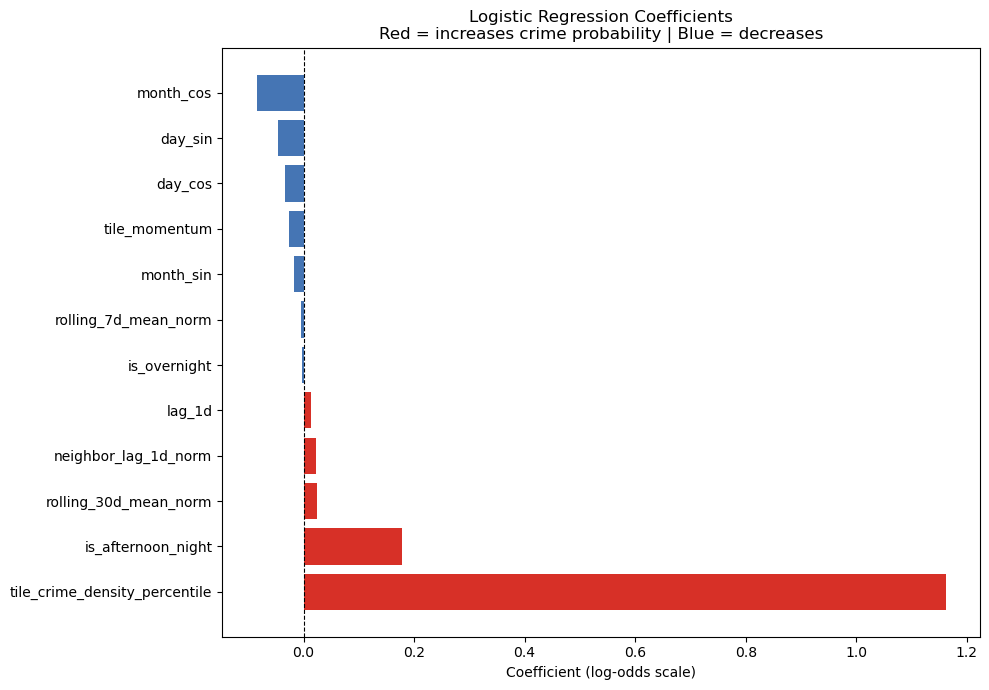

In [132]:
# -----------------------------------------------------------------------------
# Coefficient Plot — Sanity Check Feature Directions for Baseline Logistic Regression
# This is a critical sanity check to ensure that the model's learned relationships align with domain knowledge and expectations.
#
# What to look for:
#   POSITIVE coefficients (increases crime probability):
#     rolling_30d_mean_norm, rolling_7d_mean_norm, neighbor_lag_1d_norm,
#     lag_1d, tile_crime_density_percentile should all be positive
#
#   NEGATIVE coefficients (decreases crime probability):
#     some shift/time flags may be negative depending on your data distribution
#
#   RED FLAG — feature engineering bug:
#     If rolling_30d_mean_norm is negative, the normalisation is inverting
#     the signal.
# -----------------------------------------------------------------------------
print("\n" + "=" * 60)
print("LOGISTIC REGRESSION — Coefficient Plot (Feature Direction Audit)")
print("=" * 60)

# Use declared feature order from training cell (works even if preprocessor object was cloned)
all_feature_names = list(FEATURE_COLS)

coef = lr_pipeline.named_steps['classifier'].coef_[0]

if len(coef) != len(all_feature_names):
    raise ValueError(
        f"Coefficient length mismatch: {len(coef)} coefficients for "
        f"{len(all_feature_names)} features. Re-run Cell 37 and Cell 42."
    )

coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coef
}).sort_values('Coefficient', ascending=False)

print("\nCoefficients (positive = increases crime probability):")
print(coef_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#d73027' if c > 0 else '#4575b4' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient (log-odds scale)')
ax.set_title('Logistic Regression Coefficients\nRed = increases crime probability | Blue = decreases')
plt.tight_layout()
plt.show()

**Conclusion**: Logistic Regression coefficients looks ok except directional issue with rolling_7d_mean_norm and tile_momentum (as they should increase crime probability). The cause could be due to tile-level multicollinearity.

Check Variance Inflation Factor (VIF) to directly measure multicollinearity before pruning. 

In [133]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import pandas as pd

FEATURE_COLS = CATEGORICAL_COLS + NUMERIC_COLS

vif_df = final_df[FEATURE_COLS].dropna().copy()
scaler = StandardScaler()
vif_matrix = pd.DataFrame(
    scaler.fit_transform(vif_df),
    columns=FEATURE_COLS
)

vif_results = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'VIF': [
        variance_inflation_factor(vif_matrix.values, i)
        for i in range(vif_matrix.shape[1])
    ]
}).sort_values('VIF', ascending=False)

print(f"{'Feature':<35} {'VIF':>8}  Severity")
print("-"*60)
for _, row in vif_results.iterrows():
    severity = (
        "SEVERE"    if row['VIF'] > 10
        else "Moderate" if row['VIF'] > 5
        else "OK"
    )
    flag = "🔴" if row['VIF'] > 10 else "🟡" if row['VIF'] > 5 else "🟢"
    print(f"{row['Feature']:<35} {row['VIF']:>8.2f}  {flag} {severity}")

Feature                                  VIF  Severity
------------------------------------------------------------
rolling_30d_mean_norm                   3.53  🟢 OK
tile_crime_density_percentile           2.71  🟢 OK
rolling_7d_mean_norm                    2.59  🟢 OK
is_afternoon_night                      1.37  🟢 OK
tile_momentum                           1.36  🟢 OK
is_overnight                            1.34  🟢 OK
lag_1d                                  1.28  🟢 OK
neighbor_lag_1d_norm                    1.18  🟢 OK
month_cos                               1.02  🟢 OK
month_sin                               1.00  🟢 OK
day_sin                                 1.00  🟢 OK
day_cos                                 1.00  🟢 OK


**Conclusion**: VIF is clean, well below 5. Multicollinearity is not an issue. Do not need to prune any features.

Proceed to compare Logistic Regression with other models. 

In [134]:
# =========================================================================
# PIPELINE 1: Preprocessor + XGBoost
# =========================================================================
import time

print("\n" + "-"*40)
print("Training XGBoost Pipeline...")
print("-"*40)

xgb_classifier = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb_classifier)
])

# 1. Cross-validation on time-ordered subsample (each fold gets its own preprocessor fit)
print("\n   Running cross-validation...")
cv_scores = cross_val_score(
    xgb_pipeline, X_cv, y_cv,
    cv=tscv, scoring='roc_auc', n_jobs=-1
)
print(f"   CV ROC-AUC per fold : {cv_scores.round(4)}")
print(f"   Mean CV ROC-AUC     : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# 2. Final fit on full training set
print("\n   Training final model on full training set...")
start_time = time.perf_counter()
xgb_pipeline.fit(X_train, y_train)
elapsed = time.perf_counter() - start_time
print(f"   XGBoost Pipeline trained! Time taken: {elapsed:.2f}s")


----------------------------------------
Training XGBoost Pipeline...
----------------------------------------

   Running cross-validation...
   CV ROC-AUC per fold : [0.7595 0.7711 0.7783]
   Mean CV ROC-AUC     : 0.7696 (+/- 0.0077)

   Training final model on full training set...
   XGBoost Pipeline trained! Time taken: 7.33s


In [135]:
# =========================================================================
# PIPELINE 2: Preprocessor + Random Forest
# =========================================================================
print("\n" + "-"*40)
print("Training Random Forest Pipeline...")
print("-"*40)

rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

from sklearn.base import clone
rf_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', rf_classifier)
])

# 1. Cross-validation on time-ordered subsample
print("\n   Running cross-validation...")
cv_scores = cross_val_score(
    rf_pipeline, X_cv, y_cv,
    cv=tscv, scoring='roc_auc', n_jobs=-1
)
print(f"   CV ROC-AUC per fold : {cv_scores.round(4)}")
print(f"   Mean CV ROC-AUC     : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# 2. Final fit on full training set
print("\n   Training final model on full training set...")
start_time = time.perf_counter()
rf_pipeline.fit(X_train, y_train)
elapsed = time.perf_counter() - start_time
print(f"   Random Forest Pipeline trained! Time taken: {elapsed:.2f}s")


----------------------------------------
Training Random Forest Pipeline...
----------------------------------------

   Running cross-validation...
   CV ROC-AUC per fold : [0.7652 0.7707 0.7777]
   Mean CV ROC-AUC     : 0.7712 (+/- 0.0051)

   Training final model on full training set...
   Random Forest Pipeline trained! Time taken: 49.80s


In [136]:
# =========================================================================
# PIPELINE 3: Preprocessor + LightGBM
# =========================================================================
print("\n" + "-"*40)
print("Training LightGBM Pipeline...")
print("-"*40)

lgb_classifier = LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=float(scale_pos_weight),
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

from sklearn.base import clone
lgb_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', lgb_classifier)
])

# 1. Cross-validation on time-ordered subsample
print("\n   Running cross-validation...")
cv_scores = cross_val_score(
    lgb_pipeline, X_cv, y_cv,
    cv=tscv, scoring='roc_auc', n_jobs=1
)
print(f"   CV ROC-AUC per fold : {cv_scores.round(4)}")
print(f"   Mean CV ROC-AUC     : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# 2. Final fit on full training set
print("\n   Training final model on full training set...")
start_time = time.perf_counter()
lgb_pipeline.fit(X_train, y_train)
elapsed = time.perf_counter() - start_time
print(f"   LightGBM Pipeline trained! Time taken: {elapsed:.2f}s")


----------------------------------------
Training LightGBM Pipeline...
----------------------------------------

   Running cross-validation...
   CV ROC-AUC per fold : [0.749  0.765  0.7733]
   Mean CV ROC-AUC     : 0.7625 (+/- 0.0101)

   Training final model on full training set...
   LightGBM Pipeline trained! Time taken: 19.79s


---
### Step 5.5: Hyperparameter Tuning (RandomizedSearchCV) for Tree Models

Search for better hyperparameters for each model using **RandomizedSearchCV** with **TimeSeriesSplit** cross-validation to respect the temporal nature of the data and avoid leakage.

Chose RandomisedSearchCV instead of GridSearchCV due to large dataset, making random jumps to find "near-optimal" spot.

- **Tuning data**: 10% random sample of training rows, sorted chronologically
- **CV strategy**: `TimeSeriesSplit(n_splits=3)` — each fold trains on older data and validates on newer
- **Scoring**: `roc_auc` (robust to class imbalance)
- **After tuning**: best pipeline is retrained on the full training set

In [137]:
from sklearn.model_selection import RandomizedSearchCV
import time

print("="*60)
print("STEP 5.5: HYPERPARAMETER TUNING SETUP")
print("="*60)

TUNE_N = 300_000  # rows to subsample for tuning speed
N_ITER = 15       # random combinations to try per model
# N_SPLITS and tscv are defined in the TimeSeriesSplit cell above (Step 4)

# Sample from already-sorted X_train, preserving chronological order
tune_idx = (
    pd.Series(range(len(X_train)))
    .sample(n=min(TUNE_N, len(X_train)), random_state=42)
    .sort_values()   # keep rows in time order after sampling
    .values
)
X_tune = X_train.iloc[tune_idx]
y_tune = y_train.iloc[tune_idx]

print(f"\nTuning sample  : {len(X_tune):,} rows ({len(X_tune)/len(X_train)*100:.1f}% of training set)")
print(f"Positive rate  : {y_tune.mean()*100:.2f}%")
print(f"CV strategy    : TimeSeriesSplit(n_splits={N_SPLITS})")
print(f"Iterations     : {N_ITER} random combinations per model")
print(f"Scoring metric : roc_auc")

# Store tuning results for comparison at the end
tuning_results = {}

STEP 5.5: HYPERPARAMETER TUNING SETUP

Tuning sample  : 300,000 rows (10.6% of training set)
Positive rate  : 7.21%
CV strategy    : TimeSeriesSplit(n_splits=3)
Iterations     : 15 random combinations per model
Scoring metric : roc_auc


In [138]:
# =========================================================================
# TUNE 1: XGBoost
# =========================================================================
print("-"*40)
print("Tuning XGBoost...")
print("-"*40)

xgb_param_grid = {
    'classifier__n_estimators'    : [100, 200, 300],
    'classifier__max_depth'       : [4, 6, 8],
    'classifier__learning_rate'   : [0.05, 0.1, 0.2],
    'classifier__subsample'       : [0.70, 0.85, 1.0],
    'classifier__colsample_bytree': [0.70, 0.85, 1.0],
    'classifier__min_child_weight': [1, 3, 5],
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,       # existing fitted pipeline (cloned per fold)
    param_distributions=xgb_param_grid,
    n_iter=N_ITER,
    cv=tscv,
    scoring='roc_auc',
    refit=True,                    # refit best model on full X_tune/y_tune
    n_jobs=-1,
    random_state=42,
    verbose=1,
    error_score='raise'
)

t0 = time.perf_counter()
xgb_search.fit(X_tune, y_tune)
elapsed = time.perf_counter() - t0

print(f"\nBest CV ROC-AUC : {xgb_search.best_score_:.4f}")
print(f"Time taken      : {elapsed:.1f}s")
print("Best params     :")
for k, v in xgb_search.best_params_.items():
    print(f"   {k.replace('classifier__', '')}: {v}")

tuning_results['XGBoost'] = {
    'best_score': xgb_search.best_score_,
    'best_params': xgb_search.best_params_
}

# Replace pipeline variable with best estimator, then retrain on full X_train
xgb_pipeline = xgb_search.best_estimator_
xgb_pipeline.fit(X_train, y_train)
print("\nXGBoost retrained on full training set with best params.")

----------------------------------------
Tuning XGBoost...
----------------------------------------
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best CV ROC-AUC : 0.7790
Time taken      : 24.0s
Best params     :
   subsample: 1.0
   n_estimators: 200
   min_child_weight: 5
   max_depth: 4
   learning_rate: 0.05
   colsample_bytree: 0.85

XGBoost retrained on full training set with best params.


In [139]:
# =========================================================================
# TUNE 2: Random Forest
# =========================================================================
print("-"*40)
print("Tuning Random Forest...")
print("-"*40)

rf_param_grid = {
    'classifier__n_estimators'  : [100, 200, 300],
    'classifier__max_depth'     : [8, 12, 15, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf' : [1, 2, 4],
    'classifier__max_features'  : ['sqrt', 'log2'],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=N_ITER,
    cv=tscv,
    scoring='roc_auc',
    refit=True,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    error_score='raise'
)

t0 = time.perf_counter()
rf_search.fit(X_tune, y_tune)
elapsed = time.perf_counter() - t0

print(f"\nBest CV ROC-AUC : {rf_search.best_score_:.4f}")
print(f"Time taken      : {elapsed:.1f}s")
print("Best params     :")
for k, v in rf_search.best_params_.items():
    print(f"   {k.replace('classifier__', '')}: {v}")

tuning_results['RandomForest'] = {
    'best_score': rf_search.best_score_,
    'best_params': rf_search.best_params_
}

# Replace pipeline variable with best estimator, then retrain on full X_train
rf_pipeline = rf_search.best_estimator_
rf_pipeline.fit(X_train, y_train)
print("\nRandom Forest retrained on full training set with best params.")

----------------------------------------
Tuning Random Forest...
----------------------------------------
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best CV ROC-AUC : 0.7758
Time taken      : 163.0s
Best params     :
   n_estimators: 100
   min_samples_split: 2
   min_samples_leaf: 2
   max_features: sqrt
   max_depth: 8

Random Forest retrained on full training set with best params.


In [140]:
# =========================================================================
# TUNE 3: LightGBM
# =========================================================================
print("-"*40)
print("Tuning LightGBM...")
print("-"*40)

lgb_param_grid = {
    'classifier__n_estimators'  : [100, 200, 300],
    'classifier__max_depth'     : [4, 6, 8],
    'classifier__learning_rate' : [0.05, 0.1, 0.2],
    'classifier__num_leaves'    : [31, 63, 127],
    'classifier__subsample'     : [0.70, 0.85, 1.0],
    'classifier__colsample_bytree': [0.70, 0.85, 1.0],
    'classifier__min_child_samples': [10, 20, 50],
}

from sklearn.base import clone
lgb_search = RandomizedSearchCV(
    estimator=lgb_pipeline,
    param_distributions=lgb_param_grid,
    n_iter=N_ITER,
    cv=tscv,
    scoring='roc_auc',
    refit=True,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    error_score='raise'
)

t0 = time.perf_counter()
lgb_search.fit(X_tune, y_tune)
elapsed = time.perf_counter() - t0

print(f"\nBest CV ROC-AUC : {lgb_search.best_score_:.4f}")
print(f"Time taken      : {elapsed:.1f}s")
print("Best params     :")
for k, v in lgb_search.best_params_.items():
    print(f"   {k.replace('classifier__', '')}: {v}")

tuning_results['LightGBM'] = {
    'best_score': lgb_search.best_score_,
    'best_params': lgb_search.best_params_
}

# Replace pipeline variable with best estimator, then retrain on full X_train
lgb_pipeline = lgb_search.best_estimator_
lgb_pipeline.fit(X_train, y_train)
print("\nLightGBM retrained on full training set with best params.")

----------------------------------------
Tuning LightGBM...
----------------------------------------
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best CV ROC-AUC : 0.7792
Time taken      : 44.0s
Best params     :
   subsample: 0.7
   num_leaves: 63
   n_estimators: 100
   min_child_samples: 50
   max_depth: 4
   learning_rate: 0.05
   colsample_bytree: 1.0

LightGBM retrained on full training set with best params.


In [141]:
# =========================================================================
# TUNING SUMMARY: Compare best CV scores across models
# =========================================================================
print("="*60)
print("HYPERPARAMETER TUNING SUMMARY")
print("="*60)

summary_rows = []
for model_name, result in tuning_results.items():
    row = {'Model': model_name, 'Best CV ROC-AUC': round(result['best_score'], 4)}
    row.update({k.replace('classifier__', ''): v for k, v in result['best_params'].items()})
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print(summary_df.to_string())
print("\nAll four pipelines have been retrained on the full training set.")
print("Step 6 evaluation will now use the tuned models.")

HYPERPARAMETER TUNING SUMMARY
              Best CV ROC-AUC  subsample  n_estimators  min_child_weight  max_depth  learning_rate  colsample_bytree  min_samples_split  min_samples_leaf max_features  num_leaves  min_child_samples
Model                                                                                                                                                                                                
XGBoost                0.7790        1.0           200               5.0          4           0.05              0.85                NaN               NaN          NaN         NaN                NaN
RandomForest           0.7758        NaN           100               NaN          8            NaN               NaN                2.0               2.0         sqrt         NaN                NaN
LightGBM               0.7792        0.7           100               NaN          4           0.05              1.00                NaN               NaN          NaN        63.0

---
### Step 6: Evaluate Models

Evaluate using multiple metrics because accuracy alone is misleading for imbalanced data:
- **Accuracy**: Overall correct predictions (misleading if 99% are no-crime)
- **Precision**: Of predicted crime, how many are real? (avoid false alarms, if this is 15%, 1 out of every 7 dispatches finds a crime)
- **Recall**: Of actual crime, how many did we catch? (public safety, if this is 70%, we caught 7 out of 10 actual crimes)
- **F1 Score**: Balance between precision and recall
- **ROC AUC**: Model's ability to measures the model's ability to distinguish between the "Crime" and "No-Crime" classes across all possible probability thresholds.

In [142]:
print("="*60)
print("STEP 6: EVALUATE PIPELINES")
print("="*60)

def evaluate_pipeline(pipeline, X_test, y_test, name):
    """
    Evaluate a pipeline and return metrics.

    Note: X_test contains RAW features (not preprocessed).
    The pipeline handles preprocessing internally.
    """
    # Pipeline handles preprocessing + prediction in one call
    y_pred = pipeline.predict(X_test)              # Binary: 0 or 1
    y_prob = pipeline.predict_proba(X_test)[:, 1]  # Probability of crime

    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob)
    }

    print(f"\n{name} Pipeline Results:")
    print(f"   Accuracy:  {metrics['accuracy']:.4f}")
    print(f"   Precision: {metrics['precision']:.4f}")
    print(f"   Recall:    {metrics['recall']:.4f}")
    print(f"   F1 Score:  {metrics['f1_score']:.4f}")
    print(f"   ROC AUC:   {metrics['roc_auc']:.4f}")

    return metrics, y_pred, y_prob

# Evaluate pipelines (note: X_test is RAW data, pipeline handles preprocessing)
lr_metrics, lr_pred, lr_prob = evaluate_pipeline(lr_pipeline, X_test, y_test, "Logistic Regression")
xgb_metrics, xgb_pred, xgb_prob = evaluate_pipeline(xgb_pipeline, X_test, y_test, "XGBoost")
rf_metrics, rf_pred, rf_prob = evaluate_pipeline(rf_pipeline, X_test, y_test, "Random Forest")
lgb_metrics, lgb_pred, lgb_prob = evaluate_pipeline(lgb_pipeline, X_test, y_test, "LightGBM")

STEP 6: EVALUATE PIPELINES

Logistic Regression Pipeline Results:
   Accuracy:  0.6708
   Precision: 0.1381
   Recall:    0.7473
   F1 Score:  0.2331
   ROC AUC:   0.7792

XGBoost Pipeline Results:
   Accuracy:  0.6495
   Precision: 0.1342
   Recall:    0.7768
   F1 Score:  0.2288
   ROC AUC:   0.7817

Random Forest Pipeline Results:
   Accuracy:  0.6532
   Precision: 0.1343
   Recall:    0.7680
   F1 Score:  0.2287
   ROC AUC:   0.7783

LightGBM Pipeline Results:
   Accuracy:  0.6551
   Precision: 0.1352
   Recall:    0.7693
   F1 Score:  0.2299
   ROC AUC:   0.7811


**Conclusion**: The spread is still only 0.0034 ROC-AUC across all four models. While XGBoost is the best model at +0.0025 over logistic regression, that gap is smaller than CV fold variance of ±0.008. Cannot confidently say XGBoost is genuinely better than logistic regression on this dataset. Likely to hit feature ceiling.

Hence, consider Logistic Regression as it is the simplest model and has better precision than both GB models - it generates fewer false alarms per correct prediction. False alarms erodes officer's trust in patrol deployments. 

---
### Step 6.5 Operational Deployment: Threshold Calibration

At 7% base rate with 0.7792 ROC-AUC, the operational question is not which model to use but at what probability threshold to dispatch patrol units — and that decision has more impact on real-world precision/recall.

Omitted for Random Forest - least competitive model. 

STAGE 1: PROBABILITY CALIBRATION
Calibration set: 940,986 rows (2024 data)
Test set       : 938,415 rows (2025 data)
   Logistic Regression calibrated ✓
   XGBoost calibrated ✓
   LightGBM calibrated ✓


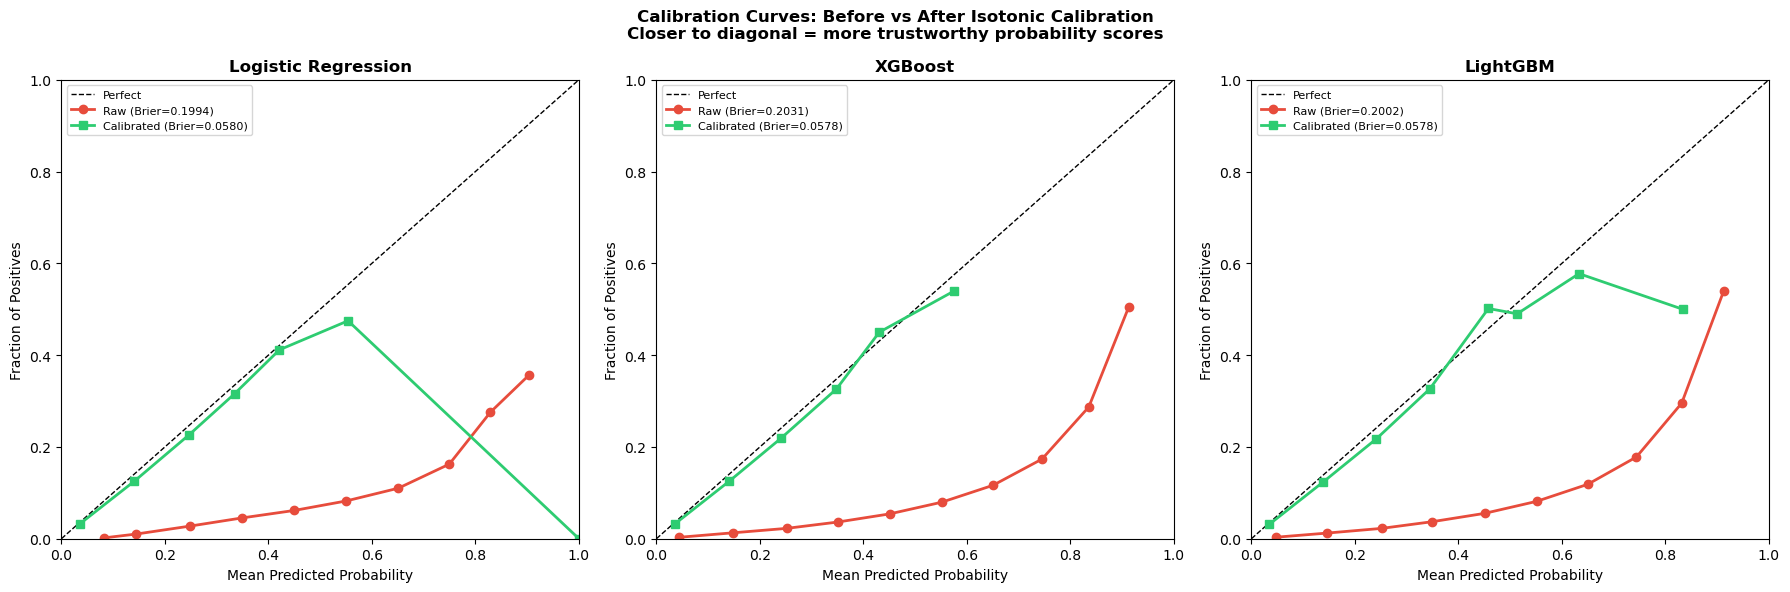


Brier Score Summary (lower = better calibrated):
Model                            Raw   Calibrated   Improvement
--------------------------------------------------------------
Logistic Regression           0.1994       0.0580       +0.1415
XGBoost                       0.2031       0.0578       +0.1454
LightGBM                      0.2002       0.0578       +0.1424

STAGE 2: THRESHOLD OPTIMISATION (on calibrated probabilities)


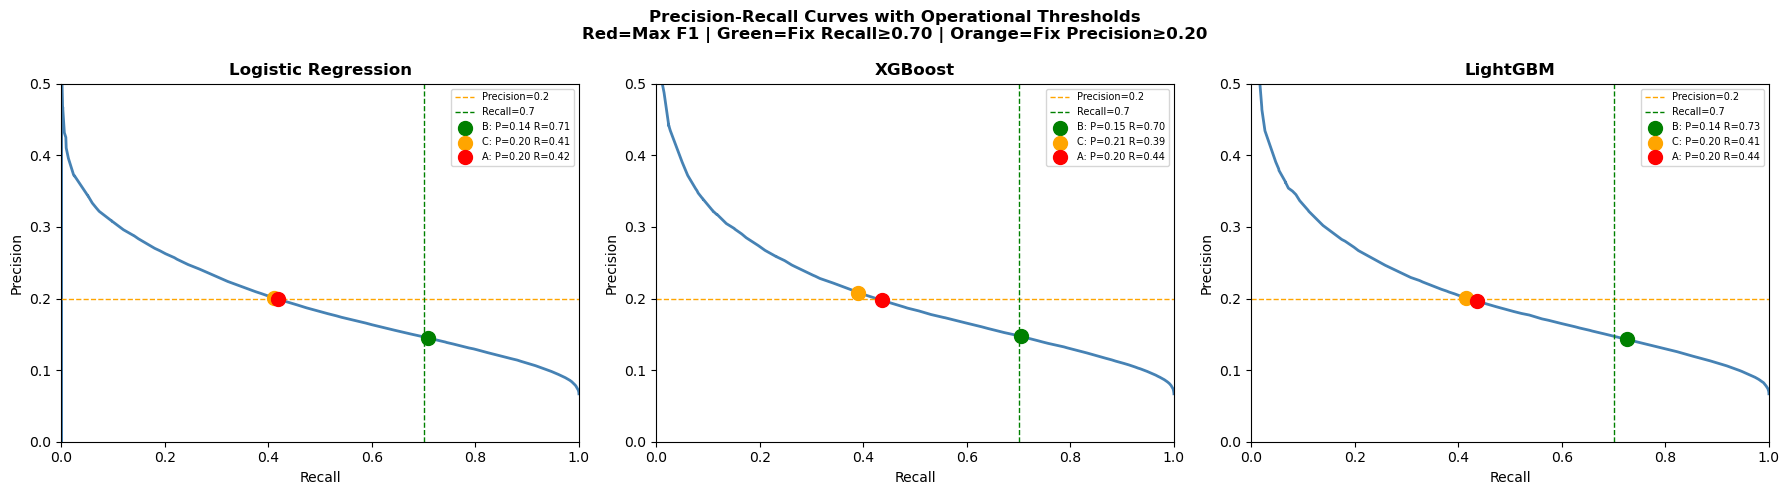


THRESHOLD OPTIMISATION SUMMARY — Calibrated Probabilities
              Model      Scenario  Threshold  Precision  Recall     F1
Logistic Regression        Max F1      0.147     0.1991  0.4176 0.2697
Logistic Regression    Recall≥0.7      0.086     0.1445  0.7092 0.2401
Logistic Regression Precision≥0.2      0.149     0.2008  0.4106 0.2697
            XGBoost        Max F1      0.150     0.1974  0.4366 0.2719
            XGBoost    Recall≥0.7      0.088     0.1471  0.7043 0.2433
            XGBoost Precision≥0.2      0.153     0.2082  0.3897 0.2714
           LightGBM        Max F1      0.146     0.1962  0.4367 0.2707
           LightGBM    Recall≥0.7      0.088     0.1428  0.7254 0.2387
           LightGBM Precision≥0.2      0.150     0.2008  0.4143 0.2705

FINAL MODEL SELECTION GUIDANCE

Scenario Max F1:
   Best model : XGBoost
   Threshold  : 0.15
   Precision  : 0.1974 (1 in 5 dispatches finds crime)
   Recall     : 0.4366 (44% of crimes caught)
   F1         : 0.2719

Scenario Re

In [145]:
# =============================================================================
# THRESHOLD CALIBRATION — All Three Competitive Models
#
# Two-stage process:
#   Stage 1: Probability calibration — fix overconfidence in raw scores
#   Stage 2: Threshold optimisation — find operating point matching
#            your operational constraint
#
# Operational constraint options:
#   - Fix precision (e.g. 1 in 5 dispatches finds a crime = 20% precision)
#   - Fix recall    (e.g. catch at least 70% of all crime events)
#   - Maximise F1   (balanced precision/recall)
# =============================================================================

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    precision_recall_curve, brier_score_loss,
    roc_auc_score, precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -----------------------------------------------------------------------------
# Stage 1: Probability Calibration using Isotonic Regression
#
# Why isotonic over Platt scaling (sigmoid):
#   Platt scaling assumes the miscalibration is sigmoid-shaped — works well
#   for SVMs. Isotonic regression is non-parametric and works better for
#   tree-based models whose miscalibration is irregular.
#   For logistic regression, calibration change will be minimal (already
#   well-calibrated) — isotonic will confirm this.
#
# Why use X_val not X_test for fitting calibration:
#   CalibratedClassifierCV with cv='prefit' fits the calibrator on data
#   you provide. Using X_test would leak test data into calibration fitting.
#   Use the last CV fold (2024 data) as calibration set.
# -----------------------------------------------------------------------------

# Use 2024 data as calibration set (held out from training, before test year)
cal_mask = final_df['Date'].dt.year.eq(2024)
X_cal = df.loc[cal_mask, FEATURE_COLS]
y_cal = df.loc[cal_mask, LABEL_COL]

print("="*60)
print("STAGE 1: PROBABILITY CALIBRATION")
print("="*60)
print(f"Calibration set: {len(X_cal):,} rows (2024 data)")
print(f"Test set       : {len(X_test):,} rows (2025 data)")

# Calibrate each model
calibrated_models = {}
raw_probs = {
    'Logistic Regression': lr_prob,
    'XGBoost'            : xgb_prob,
    'LightGBM'           : lgb_prob,
}
pipelines = {
    'Logistic Regression': lr_pipeline,
    'XGBoost'            : xgb_pipeline,
    'LightGBM'           : lgb_pipeline,
}

for name, pipeline in pipelines.items():
    cal_model = CalibratedClassifierCV(
        pipeline,
        method='isotonic',
        cv='prefit'        # pipeline already fitted — only fit calibrator
    )
    cal_model.fit(X_cal, y_cal)
    calibrated_models[name] = cal_model
    print(f"   {name} calibrated ✓")

# Get calibrated probabilities on test set
calibrated_probs = {
    name: model.predict_proba(X_test)[:, 1]
    for name, model in calibrated_models.items()
}

# -----------------------------------------------------------------------------
# Stage 1 Output: Calibration curves — before and after
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
model_names = ['Logistic Regression', 'XGBoost', 'LightGBM']
colors = {'raw': '#E74C3C', 'calibrated': '#2ECC71'}

for ax, name in zip(axes, model_names):
    # Raw probabilities
    frac_raw, mean_raw = calibration_curve(y_test, raw_probs[name], n_bins=10)
    brier_raw = brier_score_loss(y_test, raw_probs[name])

    # Calibrated probabilities
    frac_cal, mean_cal = calibration_curve(y_test, calibrated_probs[name], n_bins=10)
    brier_cal = brier_score_loss(y_test, calibrated_probs[name])

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect')
    ax.plot(mean_raw, frac_raw, 'o-', color=colors['raw'],
            linewidth=2, label=f'Raw (Brier={brier_raw:.4f})')
    ax.plot(mean_cal, frac_cal, 's-', color=colors['calibrated'],
            linewidth=2, label=f'Calibrated (Brier={brier_cal:.4f})')

    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.legend(fontsize=8)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

fig.suptitle(
    'Calibration Curves: Before vs After Isotonic Calibration\n'
    'Closer to diagonal = more trustworthy probability scores',
    fontweight='bold', fontsize=12
)
plt.tight_layout()
plt.show()

# Brier score summary
print("\nBrier Score Summary (lower = better calibrated):")
print(f"{'Model':<25} {'Raw':>10} {'Calibrated':>12} {'Improvement':>13}")
print("-"*62)
for name in model_names:
    b_raw = brier_score_loss(y_test, raw_probs[name])
    b_cal = brier_score_loss(y_test, calibrated_probs[name])
    improvement = b_raw - b_cal
    print(f"{name:<25} {b_raw:>10.4f} {b_cal:>12.4f} {improvement:>+13.4f}")

# -----------------------------------------------------------------------------
# Stage 2: Threshold Optimisation on Calibrated Probabilities
#
# Three operational scenarios:
#   A. Maximise F1          — balanced dispatch efficiency
#   B. Fix recall >= 0.70   — catch at least 70% of crime events
#   C. Fix precision >= 0.20 — 1 in 5 dispatches finds a crime
#
# Use calibrated probabilities for threshold search — thresholds on
# uncalibrated probabilities are not portable across cities or time periods
# -----------------------------------------------------------------------------
print("\n" + "="*60)
print("STAGE 2: THRESHOLD OPTIMISATION (on calibrated probabilities)")
print("="*60)

TARGET_RECALL    = 0.70   # catch 70% of all crime events
TARGET_PRECISION = 0.20   # 1 in 5 dispatches finds a crime

results = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes, model_names):
    probs = calibrated_probs[name]
    precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, probs)

    # Build threshold dataframe
    thresh_df = pd.DataFrame({
        'threshold': thresholds,
        'precision': precision_vals[:-1],
        'recall'   : recall_vals[:-1],
        'f1'       : 2 * (precision_vals[:-1] * recall_vals[:-1]) /
                     (precision_vals[:-1] + recall_vals[:-1] + 1e-9)
    })

    # Scenario A: Max F1
    best_f1_idx = thresh_df['f1'].idxmax()
    scenario_a  = thresh_df.loc[best_f1_idx]

    # Scenario B: Fix recall >= TARGET_RECALL, maximise precision
    viable_b   = thresh_df[thresh_df['recall'] >= TARGET_RECALL]
    scenario_b = viable_b.loc[viable_b['precision'].idxmax()] if len(viable_b) > 0 else None

    # Scenario C: Fix precision >= TARGET_PRECISION, maximise recall
    viable_c   = thresh_df[thresh_df['precision'] >= TARGET_PRECISION]
    scenario_c = viable_c.loc[viable_c['recall'].idxmax()] if len(viable_c) > 0 else None

    # Store results
    for scenario, label in [(scenario_a, 'Max F1'),
                             (scenario_b, f'Recall≥{TARGET_RECALL}'),
                             (scenario_c, f'Precision≥{TARGET_PRECISION}')]:
        if scenario is not None:
            results.append({
                'Model'    : name,
                'Scenario' : label,
                'Threshold': round(scenario['threshold'], 3),
                'Precision': round(scenario['precision'], 4),
                'Recall'   : round(scenario['recall'], 4),
                'F1'       : round(scenario['f1'], 4),
            })

    # Precision-Recall curve plot
    ax.plot(recall_vals, precision_vals, linewidth=2, color='steelblue')
    ax.axhline(y=TARGET_PRECISION, color='orange', linestyle='--',
               linewidth=1, label=f'Precision={TARGET_PRECISION}')
    ax.axvline(x=TARGET_RECALL, color='green', linestyle='--',
               linewidth=1, label=f'Recall={TARGET_RECALL}')

    # Mark the three operating points
    if scenario_b is not None:
        ax.scatter(scenario_b['recall'], scenario_b['precision'],
                   color='green', s=100, zorder=5,
                   label=f"B: P={scenario_b['precision']:.2f} R={scenario_b['recall']:.2f}")
    if scenario_c is not None:
        ax.scatter(scenario_c['recall'], scenario_c['precision'],
                   color='orange', s=100, zorder=5,
                   label=f"C: P={scenario_c['precision']:.2f} R={scenario_c['recall']:.2f}")
    ax.scatter(scenario_a['recall'], scenario_a['precision'],
               color='red', s=100, zorder=5,
               label=f"A: P={scenario_a['precision']:.2f} R={scenario_a['recall']:.2f}")

    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend(fontsize=7)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 0.5])

fig.suptitle(
    'Precision-Recall Curves with Operational Thresholds\n'
    'Red=Max F1 | Green=Fix Recall≥0.70 | Orange=Fix Precision≥0.20',
    fontweight='bold', fontsize=12
)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# Final Summary Table
# -----------------------------------------------------------------------------
print("\n" + "="*75)
print("THRESHOLD OPTIMISATION SUMMARY — Calibrated Probabilities")
print("="*75)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

print("\n" + "="*75)
print("FINAL MODEL SELECTION GUIDANCE")
print("="*75)

# Find best model per scenario
for scenario in results_df['Scenario'].unique():
    subset = results_df[results_df['Scenario'] == scenario]
    best   = subset.loc[subset['F1'].idxmax()]
    print(f"\nScenario {scenario}:")
    print(f"   Best model : {best['Model']}")
    print(f"   Threshold  : {best['Threshold']}")
    print(f"   Precision  : {best['Precision']} "
          f"(1 in {1/best['Precision']:.0f} dispatches finds crime)")
    print(f"   Recall     : {best['Recall']} "
          f"({best['Recall']*100:.0f}% of crimes caught)")
    print(f"   F1         : {best['F1']}")

**Conclusion**: Choose **XGBoost**. It is the best threshold calibrated model for various scenarios. 

---
### Step 7: Model Interpretation

For selected calibrated model: XGBoost

In [ ]:
# =============================================================================
# FINAL DEPLOYMENT DECISION — Choose XGBoost with Max F1 threshold for balanced operational performance
# =============================================================================

deployment_config = {
    'model'           : 'XGBoost',
    'scenario'        : 'Max F1',
    'threshold'       : 0.150,
    'precision'       : 0.1974,
    'recall'          : 0.4366,
    'f1'              : 0.2719,
    'lift_over_random': round(0.1974 / 0.0669, 2),  # precision / base rate
}

print("="*60)
print("DEPLOYMENT CONFIGURATION")
print("="*60)
print(f"Model          : {deployment_config['model']}")
print(f"Threshold      : {deployment_config['threshold']}")
print(f"Precision      : {deployment_config['precision']:.1%}")
print(f"Recall         : {deployment_config['recall']:.1%}")
print(f"F1 Score       : {deployment_config['f1']:.4f}")
print(f"Lift over random patrol : {deployment_config['lift_over_random']}x")
print()
print("Operational interpretation:")
print(f"  - 1 in {1/deployment_config['precision']:.0f} flagged tile-shifts contains a violent crime")
print(f"  - {deployment_config['recall']:.0%} of all violent crime events are flagged")
print(f"  - {deployment_config['lift_over_random']}x more efficient than uninformed patrol deployment")
print()
print("Limitation to communicate to stakeholders:")
print(f"  - {1-deployment_config['recall']:.0%} of violent crimes occur in non-flagged tiles")
print(f"  - Model is a prioritisation tool, not a coverage guarantee")
print(f"  - Baseline patrol presence still required across all areas")

DEPLOYMENT CONFIGURATION
Model          : XGBoost
Threshold      : 0.15
Precision      : 19.7%
Recall         : 43.7%
F1 Score       : 0.2719
Lift over random patrol : 2.95x

Operational interpretation:
  - 1 in 5 flagged tile-shifts contains a violent crime
  - 44% of all violent crime events are flagged
  - 2.95x more efficient than uninformed patrol deployment

Limitation to communicate to stakeholders:
  - 56% of violent crimes occur in non-flagged tiles
  - Model is a prioritisation tool, not a coverage guarantee
  - Baseline patrol presence still required across all areas


Plot precision and recall to confirm the calibrated XGBoost probabilities are well-behaved at chosen threshold — specifically that the 0.150 threshold is not sitting in a region where the precision-recall curve is unstable

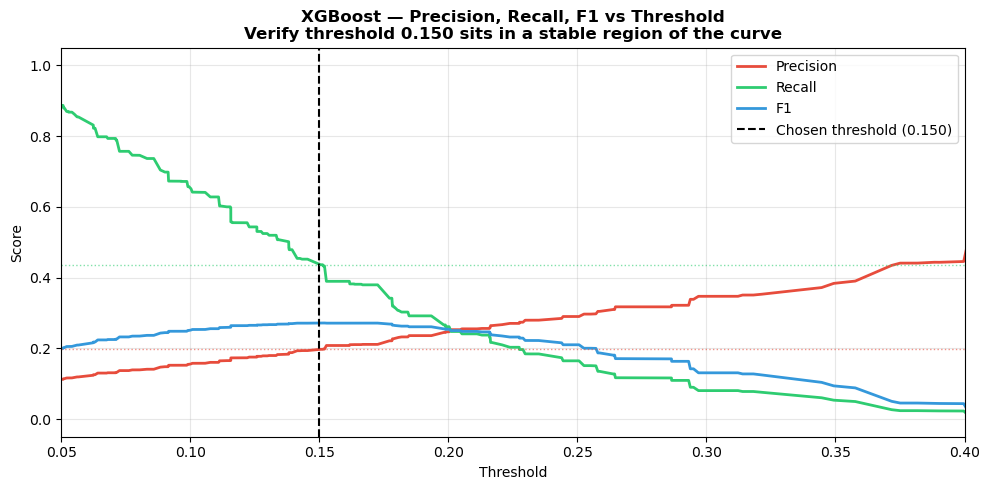


Threshold stability check (0.13 – 0.17):
 Threshold  Precision  Recall     F1
    0.1305     0.1799  0.5198 0.2673
    0.1332     0.1799  0.5198 0.2673
    0.1337     0.1827  0.5072 0.2686
    0.1341     0.1827  0.5072 0.2686
    0.1342     0.1827  0.5072 0.2686
    0.1343     0.1827  0.5072 0.2686
    0.1381     0.1837  0.5016 0.2689
    0.1381     0.1866  0.4851 0.2696
    0.1382     0.1866  0.4851 0.2696
    0.1383     0.1881  0.4790 0.2701
    0.1390     0.1881  0.4790 0.2701
    0.1391     0.1881  0.4790 0.2701
    0.1391     0.1881  0.4790 0.2701
    0.1394     0.1881  0.4790 0.2701
    0.1414     0.1935  0.4544 0.2714
    0.1424     0.1935  0.4544 0.2714
    0.1433     0.1939  0.4523 0.2714
    0.1441     0.1939  0.4523 0.2714
    0.1454     0.1939  0.4523 0.2714
    0.1504     0.1974  0.4366 0.2719
    0.1512     0.1974  0.4365 0.2719
    0.1515     0.1981  0.4330 0.2718
    0.1518     0.1981  0.4330 0.2718
    0.1520     0.1981  0.4330 0.2718
    0.1527     0.2082  0.3897 0.2

In [148]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

probs = calibrated_probs['XGBoost']
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, probs)

# Plot precision and recall as a function of threshold
# You want both curves to be smooth around 0.150 — a jagged curve
# at that point means the threshold is unstable and small changes
# in the model would shift performance significantly
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(thresholds, precision_vals[:-1], color='#E74C3C',
        linewidth=2, label='Precision')
ax.plot(thresholds, recall_vals[:-1], color='#2ECC71',
        linewidth=2, label='Recall')
ax.plot(thresholds,
        2 * (precision_vals[:-1] * recall_vals[:-1]) /
        (precision_vals[:-1] + recall_vals[:-1] + 1e-9),
        color='#3498DB', linewidth=2, label='F1')

# Mark chosen threshold
ax.axvline(x=0.150, color='black', linestyle='--',
           linewidth=1.5, label='Chosen threshold (0.150)')
ax.axhline(y=0.1974, color='#E74C3C', linestyle=':',
           linewidth=1, alpha=0.6)
ax.axhline(y=0.4366, color='#2ECC71', linestyle=':',
           linewidth=1, alpha=0.6)

ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('XGBoost — Precision, Recall, F1 vs Threshold\n'
             'Verify threshold 0.150 sits in a stable region of the curve',
             fontweight='bold')
ax.legend()
ax.set_xlim([0.05, 0.40])  # focus on the relevant range
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print behaviour around chosen threshold to check stability
mask = (thresholds >= 0.13) & (thresholds <= 0.17)
check_df = pd.DataFrame({
    'Threshold': thresholds[mask],
    'Precision': precision_vals[:-1][mask],
    'Recall'   : recall_vals[:-1][mask],
    'F1'       : (2 * precision_vals[:-1][mask] * recall_vals[:-1][mask] /
                 (precision_vals[:-1][mask] + recall_vals[:-1][mask] + 1e-9))
}).round(4)

print("\nThreshold stability check (0.13 – 0.17):")
print(check_df.to_string(index=False))
print("\nIf precision and recall change smoothly across this range,")
print("the threshold is stable and safe to deploy.")

Explain XGBoost model results and threshold selection for deployment, including calibration and operational interpretation.

CONFUSION MATRIX — XGBoost @ Threshold 0.15

Raw Counts:
   True Negatives  (TN):    764,127  correctly predicted no crime
   False Positives (FP):    111,474  predicted crime, no crime occurred
   False Negatives (FN):     35,392  missed crime events
   True Positives  (TP):     27,422  correctly predicted crime

   Total test rows     :    938,415
   Actual crime events :     62,814 (6.7% base rate)
   Flagged tile-shifts :    138,896 (14.8% of all shifts)

Operational Metrics:
   Precision  : 0.1974  — 1 in 5 flagged shifts has a crime
   Recall     : 0.4366  — catches 44% of all crime events
   F1 Score   : 0.2719
   Specificity: 0.8727  — correctly clears 87% of no-crime shifts
   Lift       : 2.95x vs 6.7% base rate (random patrol)


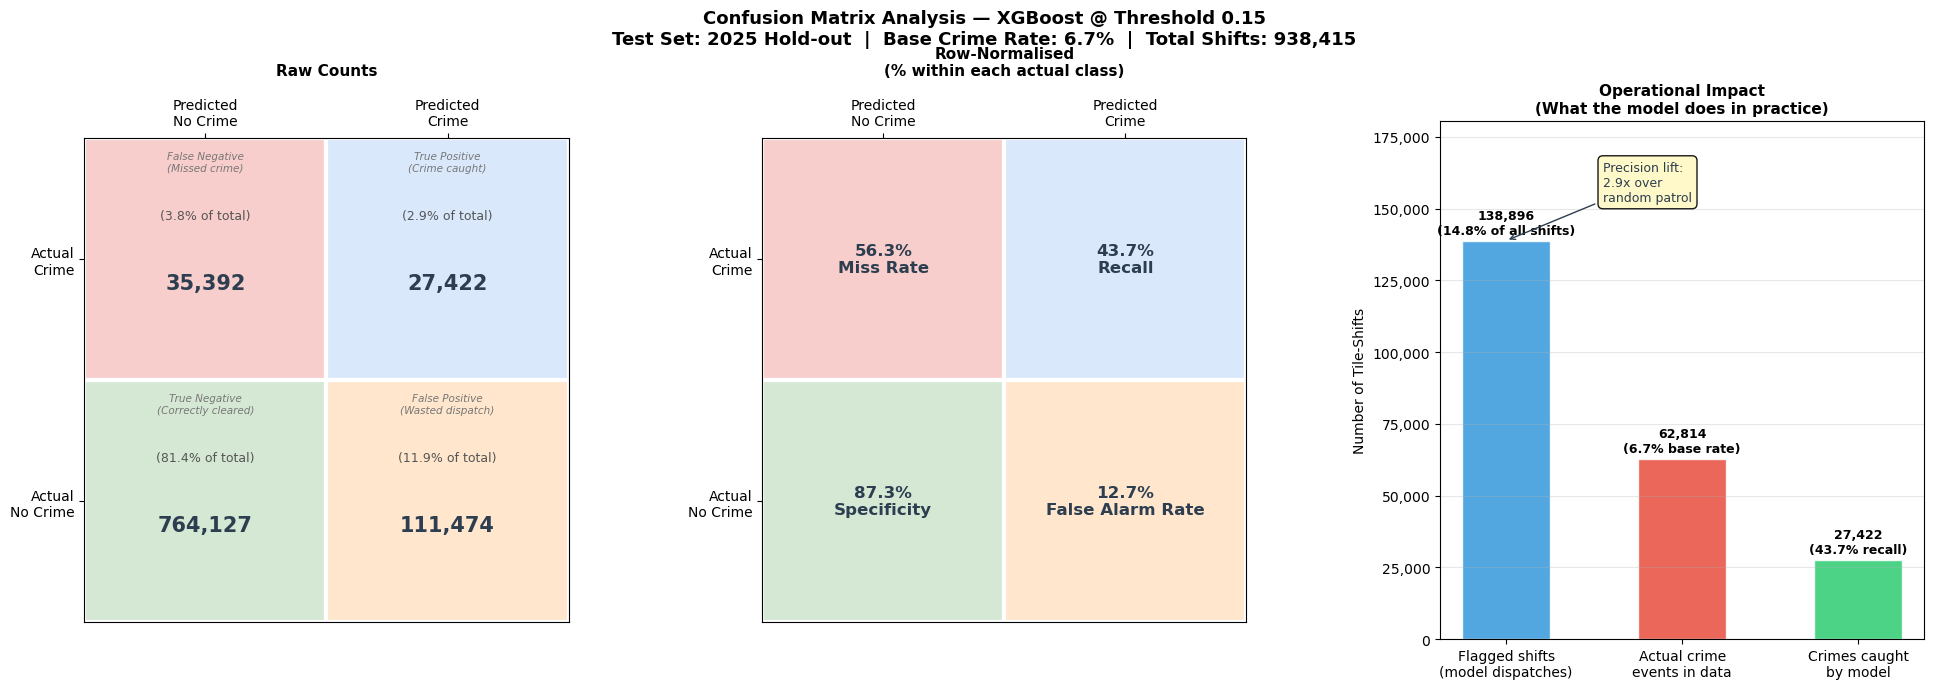


Classification Report:
              precision    recall  f1-score   support

    No Crime     0.9557    0.8727    0.9123    875601
       Crime     0.1974    0.4366    0.2719     62814

    accuracy                         0.8435    938415
   macro avg     0.5766    0.6546    0.5921    938415
weighted avg     0.9050    0.8435    0.8695    938415



In [152]:
# =============================================================================
# CONFUSION MATRIX — XGBoost at Threshold 0.150 (Calibrated)
# Fixed: title spacing, axis label positions, annotation clipping
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

THRESHOLD  = 0.150
MODEL_NAME = 'XGBoost'
probs      = calibrated_probs[MODEL_NAME]
BASE_RATE  = y_test.mean()

y_pred_thresh = (probs >= THRESHOLD).astype(int)

cm             = confusion_matrix(y_test, y_pred_thresh)
tn, fp, fn, tp = cm.ravel()
total          = len(y_test)

print("="*60)
print(f"CONFUSION MATRIX — {MODEL_NAME} @ Threshold {THRESHOLD}")
print("="*60)
print(f"\nRaw Counts:")
print(f"   True Negatives  (TN): {tn:>10,}  correctly predicted no crime")
print(f"   False Positives (FP): {fp:>10,}  predicted crime, no crime occurred")
print(f"   False Negatives (FN): {fn:>10,}  missed crime events")
print(f"   True Positives  (TP): {tp:>10,}  correctly predicted crime")
print(f"\n   Total test rows     : {total:>10,}")
print(f"   Actual crime events : {tp+fn:>10,} ({BASE_RATE:.1%} base rate)")
print(f"   Flagged tile-shifts : {tp+fp:>10,} ({(tp+fp)/total:.1%} of all shifts)")
print(f"\nOperational Metrics:")
print(f"   Precision  : {tp/(tp+fp):.4f}  — 1 in {(tp+fp)/tp:.0f} flagged shifts has a crime")
print(f"   Recall     : {tp/(tp+fn):.4f}  — catches {tp/(tp+fn):.0%} of all crime events")
print(f"   F1 Score   : {2*tp/(2*tp+fp+fn):.4f}")
print(f"   Specificity: {tn/(tn+fp):.4f}  — correctly clears {tn/(tn+fp):.0%} of no-crime shifts")
print(f"   Lift       : {(tp/(tp+fp))/BASE_RATE:.2f}x vs {BASE_RATE:.1%} base rate (random patrol)")

# -----------------------------------------------------------------------------
# Layout: use constrained_layout + explicit top margin for suptitle
# Each panel gets its own clearly separated space
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(20, 7))
fig.subplots_adjust(top=0.82, bottom=0.08, left=0.05,
                    right=0.97, wspace=0.40)

# Shared suptitle with enough headroom
fig.suptitle(
    f'Confusion Matrix Analysis — {MODEL_NAME} @ Threshold {THRESHOLD}\n'
    f'Test Set: 2025 Hold-out  |  Base Crime Rate: {BASE_RATE:.1%}  '
    f'|  Total Shifts: {total:,}',
    fontweight='bold', fontsize=13,
    y=0.98          # sits above subplots, no overlap
)

cell_colors = [['#D5E8D4', '#FFE6CC'],   # TN=green, FP=orange
               ['#F8CECC', '#DAE8FC']]   # FN=red,   TP=blue

# ── Panel 1: Raw count confusion matrix ──────────────────────────────────────
ax1 = fig.add_subplot(1, 3, 1)
ax1.set_xlim(-0.5, 1.5)
ax1.set_ylim(-0.5, 1.5)
ax1.set_aspect('equal')

cm_display = np.array([[tn, fp], [fn, tp]])
quad_labels = [
    ['True Negative\n(Correctly cleared)',  'False Positive\n(Wasted dispatch)'],
    ['False Negative\n(Missed crime)',       'True Positive\n(Crime caught)']
]

for i in range(2):
    for j in range(2):
        count = cm_display[i, j]
        pct   = count / total
        ax1.add_patch(plt.Rectangle(
            (j - 0.5, i - 0.5), 1, 1,
            facecolor=cell_colors[i][j],
            edgecolor='white', linewidth=3
        ))
        # Large count
        ax1.text(j, i - 0.10, f'{count:,}',
                 ha='center', va='center',
                 fontsize=15, fontweight='bold', color='#2C3E50')
        # Percentage of total
        ax1.text(j, i + 0.18, f'({pct:.1%} of total)',
                 ha='center', va='center',
                 fontsize=9, color='#555555')
        # Quadrant label
        ax1.text(j, i + 0.40, quad_labels[i][j],
                 ha='center', va='center',
                 fontsize=7.5, color='#777777', style='italic')

# x-axis on top (Predicted)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Predicted\nNo Crime', 'Predicted\nCrime'],
                    fontsize=10)
ax1.xaxis.set_label_position('top')
ax1.xaxis.tick_top()

# y-axis on left (Actual)
ax1.set_yticks([0, 1])
ax1.set_yticklabels(['Actual\nNo Crime', 'Actual\nCrime'],
                    fontsize=10)

ax1.set_title('Raw Counts', fontweight='bold',
              fontsize=11, pad=45)   # pad pushes title above top x-axis labels

# ── Panel 2: Row-normalised confusion matrix ──────────────────────────────────
ax2 = fig.add_subplot(1, 3, 2)
ax2.set_xlim(-0.5, 1.5)
ax2.set_ylim(-0.5, 1.5)
ax2.set_aspect('equal')

# Row normalisation: row 0 = actual no-crime, row 1 = actual crime
cm_norm      = cm_display.astype(float)
cm_norm[0]   = cm_norm[0] / cm_norm[0].sum()
cm_norm[1]   = cm_norm[1] / cm_norm[1].sum()

norm_labels = [
    [f'{cm_norm[0,0]:.1%}\nSpecificity',    f'{cm_norm[0,1]:.1%}\nFalse Alarm Rate'],
    [f'{cm_norm[1,0]:.1%}\nMiss Rate',      f'{cm_norm[1,1]:.1%}\nRecall']
]

for i in range(2):
    for j in range(2):
        ax2.add_patch(plt.Rectangle(
            (j - 0.5, i - 0.5), 1, 1,
            facecolor=cell_colors[i][j],
            edgecolor='white', linewidth=3
        ))
        ax2.text(j, i, norm_labels[i][j],
                 ha='center', va='center',
                 fontsize=12, fontweight='bold', color='#2C3E50')

# x-axis on top (Predicted)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Predicted\nNo Crime', 'Predicted\nCrime'],
                    fontsize=10)
ax2.xaxis.set_label_position('top')
ax2.xaxis.tick_top()

# y-axis on left (Actual)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Actual\nNo Crime', 'Actual\nCrime'],
                    fontsize=10)

ax2.set_title('Row-Normalised\n(% within each actual class)',
              fontweight='bold', fontsize=11, pad=45)

# ── Panel 3: Operational impact bar chart ─────────────────────────────────────
ax3 = fig.add_subplot(1, 3, 3)

categories = [
    'Flagged shifts\n(model dispatches)',
    'Actual crime\nevents in data',
    'Crimes caught\nby model'
]
values      = [tp + fp, tp + fn, tp]
bar_colors  = ['#3498DB', '#E74C3C', '#2ECC71']
bars        = ax3.bar(categories, values,
                      color=bar_colors, alpha=0.85,
                      edgecolor='white', width=0.5)

# Set y-axis ceiling with 25% headroom so annotations don't clip
ax3.set_ylim(0, max(values) * 1.30)

annotations = [
    f"{tp+fp:,}\n({(tp+fp)/total:.1%} of all shifts)",
    f"{tp+fn:,}\n({BASE_RATE:.1%} base rate)",
    f"{tp:,}\n({tp/(tp+fn):.1%} recall)"
]
for bar, ann in zip(bars, annotations):
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(values) * 0.01,   # consistent gap above bar
        ann,
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )

# Precision lift annotation — placed inside the plot area
ax3.annotate(
    f'Precision lift:\n{(tp/(tp+fp))/BASE_RATE:.1f}x over\nrandom patrol',
    xy=(0, tp + fp),
    xytext=(0.55, max(values) * 1.10),
    fontsize=9, color='#2C3E50',
    bbox=dict(boxstyle='round,pad=0.4',
              facecolor='#FFF9C4', alpha=0.9),
    arrowprops=dict(arrowstyle='->', color='#2C3E50')
)

ax3.set_ylabel('Number of Tile-Shifts', fontsize=10)
ax3.set_title('Operational Impact\n(What the model does in practice)',
              fontweight='bold', fontsize=11)
ax3.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda val, _: f'{int(val):,}')
)
ax3.grid(axis='y', alpha=0.3)

plt.savefig('confusion_matrix.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

# -----------------------------------------------------------------------------
# Classification report
# -----------------------------------------------------------------------------
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred_thresh,
    target_names=['No Crime', 'Crime'],
    digits=4
))

METHOD 1: BUILT-IN XGBOOST FEATURE IMPORTANCE

Built-in Importance (normalised to 100%, sorted by Gain):
Feature                                 Gain   Weight    Cover
--------------------------------------------------------------
tile_crime_density_percentile         78.31%   31.57%   39.84%
rolling_30d_mean_norm                 12.30%   11.03%   11.01%
tile_momentum                          4.31%   15.00%   12.05%
is_afternoon_night                     1.96%    9.12%    8.05%
rolling_7d_mean_norm                   0.89%    2.64%    1.25%
month_cos                              0.60%    7.95%   10.43%
day_sin                                0.53%    5.91%    5.15%
is_overnight                           0.47%    4.61%    3.98%
neighbor_lag_1d_norm                   0.46%    6.38%    4.50%
day_cos                                0.13%    2.57%    1.47%
month_sin                              0.03%    2.14%    0.26%
lag_1d                                 0.02%    1.07%    2.03%


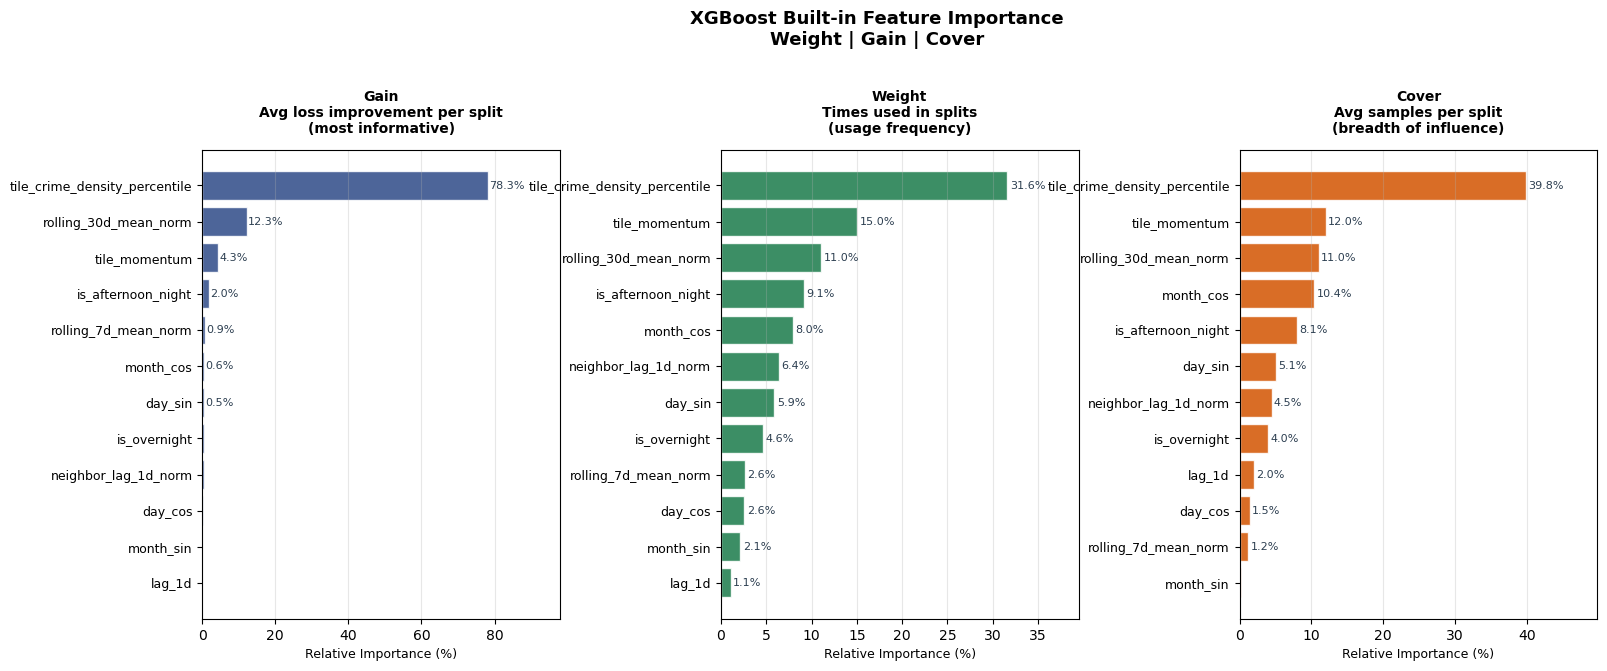


METHOD 2: PERMUTATION IMPORTANCE (ROC-AUC drop on test set)

Permutation Importance (drop in ROC-AUC when feature shuffled):
Feature                                Mean Drop    Std Dev  Interpretation
---------------------------------------------------------------------------
tile_crime_density_percentile           +0.24985    0.00144  High importance
is_afternoon_night                      +0.00654    0.00016  Moderate
day_sin                                 +0.00222    0.00005  Low / noise
month_cos                               +0.00196    0.00007  Low / noise
is_overnight                            +0.00188    0.00007  Low / noise
tile_momentum                           +0.00186    0.00006  Low / noise
rolling_30d_mean_norm                   +0.00084    0.00010  Low / noise
day_cos                                 +0.00034    0.00003  Low / noise
neighbor_lag_1d_norm                    +0.00013    0.00003  Low / noise
lag_1d                                  +0.00005    0.00001  Low

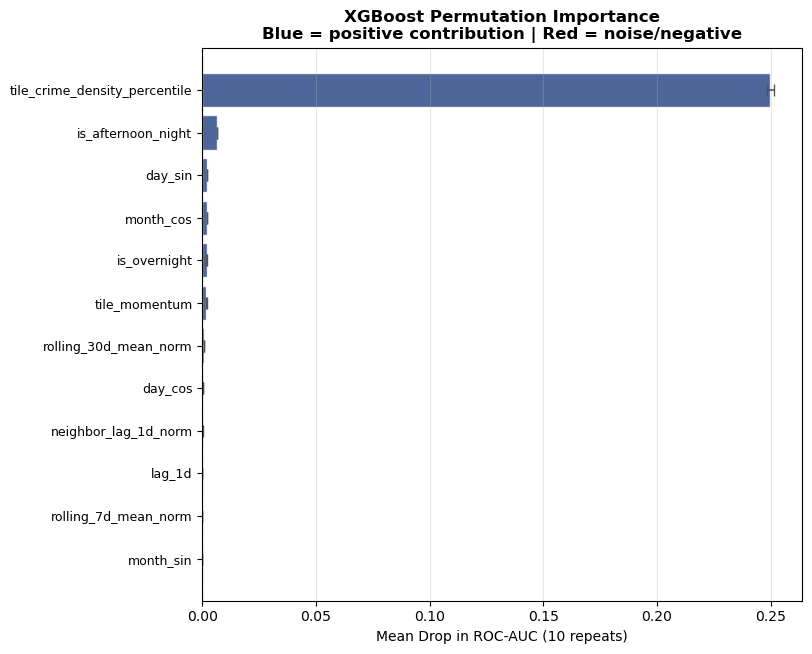


METHOD 3: SHAP VALUES
SHAP values computed on 5,000 test samples


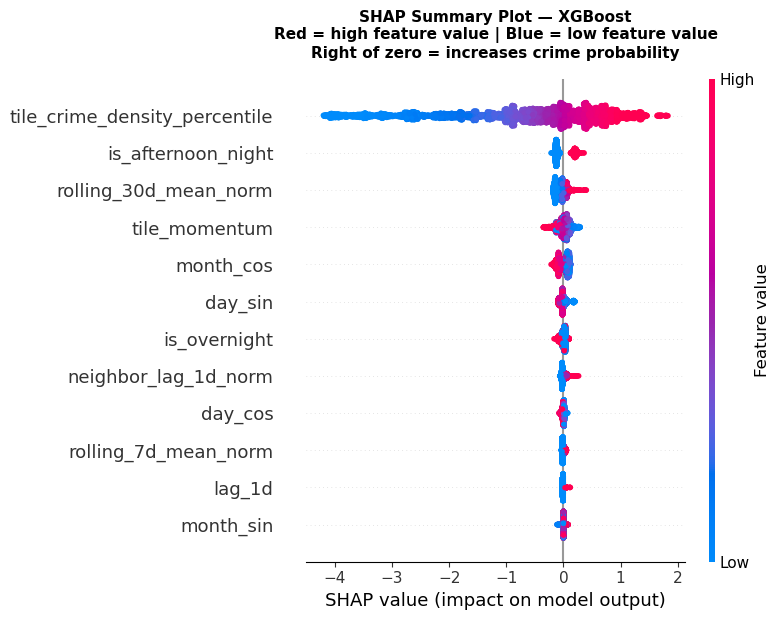

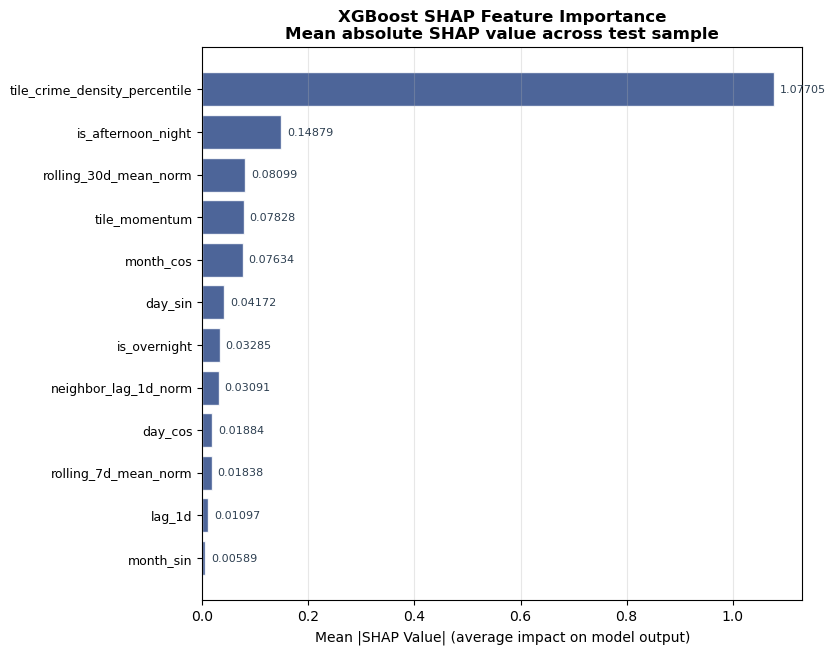


Mean |SHAP| per feature (sorted by importance):
Feature                                Mean |SHAP|  Interpretation
----------------------------------------------------------------------
tile_crime_density_percentile             1.077052  Dominant
is_afternoon_night                        0.148788  Dominant
rolling_30d_mean_norm                     0.080988  Dominant
tile_momentum                             0.078280  Dominant
month_cos                                 0.076341  Dominant
day_sin                                   0.041723  Dominant
is_overnight                              0.032848  Dominant
neighbor_lag_1d_norm                      0.030912  Dominant
day_cos                                   0.018840  Dominant
rolling_7d_mean_norm                      0.018379  Dominant
lag_1d                                    0.010971  Dominant
month_sin                                 0.005893  Strong

FEATURE IMPORTANCE COMPARISON — Gain vs Permutation vs SHAP
(Rank 1 = most importa

In [160]:
# =============================================================================
# FEATURE IMPORTANCE — XGBoost (Three Methods)
#
# Method 1: Built-in XGBoost importance (weight/gain/cover)
#   - Weight  : number of times a feature is used to split across all trees
#   - Gain    : average improvement in loss when a feature is used to split
#   - Cover   : average number of samples affected by splits on this feature
#   Gain is the most informative for understanding predictive contribution
#
# Method 2: Permutation importance (model-agnostic)
#   - Measures actual ROC-AUC drop when each feature is randomly shuffled
#   - More reliable than built-in importance for correlated features
#   - Slower but reflects true predictive value on the test set
#
# Method 3: SHAP values
#   - Shows directional contribution of each feature to each prediction
#   - Reveals whether high feature values increase or decrease crime probability
#   - Most complete picture of how the model uses each feature
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

# =============================================================================
# METHOD 1: Built-in XGBoost Feature Importance (Weight, Gain, Cover)
# =============================================================================
print("="*60)
print("METHOD 1: BUILT-IN XGBOOST FEATURE IMPORTANCE")
print("="*60)

# Extract fitted XGBoost model from pipeline
xgb_model    = xgb_pipeline.named_steps['classifier']
feature_names = list(X_train.columns)
booster = xgb_model.get_booster()

# Get all three importance types
importance_types = {
    'Gain'  : 'total_gain',    # most informative — predictive contribution
    'Weight': 'weight',        # how often feature is used to split
    'Cover' : 'total_cover'    # how many samples go through splits on feature
}

imp_dfs = {}
for label, imp_type in importance_types.items():
    scores = booster.get_score(importance_type=imp_type)
    # Booster keys are often f0, f1, ... after preprocessing; map robustly.
    imp_df = pd.DataFrame([
        {'Feature': f, label: float(scores.get(f, scores.get(f'f{i}', 0.0)))}
        for i, f in enumerate(feature_names)
    ]).sort_values(label, ascending=False)
    # Normalise to sum = 100 for comparability; guard all-zero totals.
    total = imp_df[label].sum()
    if np.isfinite(total) and total > 0:
        imp_df[label] = imp_df[label] / total * 100
    else:
        imp_df[label] = 0.0
    imp_dfs[label] = imp_df

# Print table
print("\nBuilt-in Importance (normalised to 100%, sorted by Gain):")
print(f"{'Feature':<35} {'Gain':>8} {'Weight':>8} {'Cover':>8}")
print("-"*62)
merged = imp_dfs['Gain'].merge(
    imp_dfs['Weight'][['Feature','Weight']], on='Feature'
).merge(
    imp_dfs['Cover'][['Feature','Cover']], on='Feature'
).sort_values('Gain', ascending=False)

for _, row in merged.iterrows():
    print(f"{row['Feature']:<35} {row['Gain']:>7.2f}% "
          f"{row['Weight']:>7.2f}% {row['Cover']:>7.2f}%")

# Plot: three side-by-side horizontal bars
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.subplots_adjust(top=0.78, wspace=0.45)

colors   = {'Gain': '#2E4A87', 'Weight': '#1A7A4A', 'Cover': '#D35400'}
subtitles = {
    'Gain'  : 'Avg loss improvement per split\n(most informative)',
    'Weight': 'Times used in splits\n(usage frequency)',
    'Cover' : 'Avg samples per split\n(breadth of influence)'
}

for ax, (label, imp_df) in zip(axes, imp_dfs.items()):
    df_plot = imp_df.sort_values(label, ascending=True).copy()
    plot_vals = pd.to_numeric(df_plot[label], errors='coerce').replace([np.inf, -np.inf], np.nan).fillna(0.0)
    bars = ax.barh(df_plot['Feature'], plot_vals,
                   color=colors[label], alpha=0.85, edgecolor='white')
    # Annotate values
    for bar, val in zip(bars, plot_vals):
        if val > 0.5:
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', fontsize=8, color='#2C3E50')
    ax.set_title(f'{label}\n{subtitles[label]}',
                 fontweight='bold', fontsize=10, pad=12)
    ax.set_xlabel('Relative Importance (%)', fontsize=9)
    x_max = float(plot_vals.max()) if len(plot_vals) else 0.0
    if not np.isfinite(x_max) or x_max <= 0:
        x_max = 1.0
    ax.set_xlim(0, x_max * 1.25)
    ax.grid(axis='x', alpha=0.3)
    ax.tick_params(axis='y', labelsize=9)

fig.suptitle('XGBoost Built-in Feature Importance\n'
             'Weight | Gain | Cover',
             fontweight='bold', fontsize=13, y=0.98)
plt.savefig('xgb_builtin_importance.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

# =============================================================================
# METHOD 2: Permutation Importance on Test Set
# =============================================================================
print("\n" + "="*60)
print("METHOD 2: PERMUTATION IMPORTANCE (ROC-AUC drop on test set)")
print("="*60)

from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    xgb_pipeline, X_test, y_test,
    n_repeats=10,           # shuffle each feature 10 times for stable estimates
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Mean_Drop'  : perm_result.importances_mean,
    'Std_Drop'   : perm_result.importances_std
}).sort_values('Mean_Drop', ascending=False)

print("\nPermutation Importance (drop in ROC-AUC when feature shuffled):")
print(f"{'Feature':<35} {'Mean Drop':>12} {'Std Dev':>10}  Interpretation")
print("-"*75)
for _, row in perm_df.iterrows():
    interp = (
        "High importance"    if row['Mean_Drop'] > 0.01
        else "Moderate"      if row['Mean_Drop'] > 0.003
        else "Low / noise"   if row['Mean_Drop'] > 0
        else "Negative \u2014 noise"
    )
    print(f"{row['Feature']:<35} {row['Mean_Drop']:>+12.5f} "
          f"{row['Std_Drop']:>10.5f}  {interp}")

# Plot with error bars
fig, ax = plt.subplots(figsize=(10, 7))
fig.subplots_adjust(top=0.90, left=0.30)

df_plot = perm_df.sort_values('Mean_Drop', ascending=True)
colors_perm = ['#2E4A87' if v > 0 else '#C0392B'
               for v in df_plot['Mean_Drop']]

ax.barh(df_plot['Feature'], df_plot['Mean_Drop'],
        xerr=df_plot['Std_Drop'],
        color=colors_perm, alpha=0.85, edgecolor='white',
        error_kw={'ecolor': '#555555', 'capsize': 4, 'linewidth': 1.2})

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Mean Drop in ROC-AUC (10 repeats)', fontsize=10)
ax.set_title('XGBoost Permutation Importance\n'
             'Blue = positive contribution | Red = noise/negative',
             fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3)
ax.tick_params(axis='y', labelsize=9)

plt.savefig('xgb_permutation_importance.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

# =============================================================================
# METHOD 3: SHAP Values
# =============================================================================
print("\n" + "="*60)
print("METHOD 3: SHAP VALUES")
print("="*60)

try:
    import shap

    # Use a subsample for speed — SHAP is O(n * trees * depth)
    # 5,000 rows gives stable mean SHAP values without excessive runtime
    SHAP_SAMPLE = 5000
    shap_idx = np.random.RandomState(42).choice(
        len(X_test), size=min(SHAP_SAMPLE, len(X_test)), replace=False
    )
    X_shap_raw = X_test.iloc[shap_idx]

    # Transform through pipeline preprocessor to get the encoded matrix
    # SHAP TreeExplainer operates on the model directly, needs encoded input
    preprocessor_fitted = xgb_pipeline.named_steps['preprocessor']
    X_shap_encoded = preprocessor_fitted.transform(X_shap_raw)

    # Rebuild column names after ColumnTransformer
    cat_cols = preprocessor_fitted.transformers_[0][2]
    num_cols = preprocessor_fitted.transformers_[1][2]
    encoded_feature_names = list(cat_cols) + list(num_cols)

    X_shap_df = pd.DataFrame(X_shap_encoded, columns=encoded_feature_names)

    # SHAP TreeExplainer — fast, exact for tree models
    explainer  = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_shap_df)

    print(f"SHAP values computed on {SHAP_SAMPLE:,} test samples")

    # ── Plot 1: SHAP Summary (Beeswarm) ──────────────────────────────────────
    # Each dot = one sample; x-axis = SHAP value; colour = feature value
    # Positive SHAP = increases crime probability
    # Negative SHAP = decreases crime probability
    fig, ax = plt.subplots(figsize=(10, 8))
    shap.summary_plot(
        shap_values, X_shap_df,
        feature_names=encoded_feature_names,
        plot_type='dot',
        show=False,
        max_display=12
    )
    plt.title('SHAP Summary Plot — XGBoost\n'
              'Red = high feature value | Blue = low feature value\n'
              'Right of zero = increases crime probability',
              fontweight='bold', fontsize=11, pad=15)
    plt.tight_layout()
    plt.savefig('xgb_shap_beeswarm.png', dpi=150,
                bbox_inches='tight', facecolor='white')
    plt.show()

    # ── Plot 2: SHAP Mean Absolute Importance Bar ─────────────────────────────
    # Mean |SHAP| = average magnitude of impact on model output
    # Clean single-bar chart sorted by importance
    mean_abs_shap = pd.DataFrame({
        'Feature'        : encoded_feature_names,
        'Mean_Abs_SHAP'  : np.abs(shap_values).mean(axis=0)
    }).sort_values('Mean_Abs_SHAP', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 7))
    fig.subplots_adjust(top=0.90, left=0.30)

    bars = ax.barh(mean_abs_shap['Feature'],
                   mean_abs_shap['Mean_Abs_SHAP'],
                   color='#2E4A87', alpha=0.85, edgecolor='white')

    for bar, val in zip(bars, mean_abs_shap['Mean_Abs_SHAP']):
        ax.text(bar.get_width() + mean_abs_shap['Mean_Abs_SHAP'].max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.5f}', va='center', fontsize=8, color='#2C3E50')

    ax.set_xlabel('Mean |SHAP Value| (average impact on model output)', fontsize=10)
    ax.set_title('XGBoost SHAP Feature Importance\n'
                 'Mean absolute SHAP value across test sample',
                 fontweight='bold', fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    ax.tick_params(axis='y', labelsize=9)
    plt.savefig('xgb_shap_bar.png', dpi=150,
                bbox_inches='tight', facecolor='white')
    plt.show()

    # ── Print SHAP summary table ──────────────────────────────────────────────
    print("\nMean |SHAP| per feature (sorted by importance):")
    print(f"{'Feature':<35} {'Mean |SHAP|':>14}  Interpretation")
    print("-"*70)
    for _, row in mean_abs_shap.sort_values(
            'Mean_Abs_SHAP', ascending=False).iterrows():
        interp = (
            "Dominant"   if row['Mean_Abs_SHAP'] > 0.01
            else "Strong"    if row['Mean_Abs_SHAP'] > 0.005
            else "Moderate"  if row['Mean_Abs_SHAP'] > 0.001
            else "Weak"
        )
        print(f"{row['Feature']:<35} {row['Mean_Abs_SHAP']:>14.6f}  {interp}")

except ImportError:
    print("SHAP not installed. Run: pip install shap --break-system-packages")
    print("Skipping SHAP analysis.")

# =============================================================================
# COMPARISON TABLE — All Three Methods Side by Side
# =============================================================================
print("\n" + "="*70)
print("FEATURE IMPORTANCE COMPARISON — Gain vs Permutation vs SHAP")
print("="*70)
print("(Rank 1 = most important per method)\n")

gain_ranked  = imp_dfs['Gain'].sort_values('Gain', ascending=False).reset_index(drop=True)
perm_ranked  = perm_df.sort_values('Mean_Drop', ascending=False).reset_index(drop=True)

gain_rank  = {row['Feature']: i+1 for i, row in gain_ranked.iterrows()}
perm_rank  = {row['Feature']: i+1 for i, row in perm_ranked.iterrows()}

try:
    shap_ranked = mean_abs_shap.sort_values(
        'Mean_Abs_SHAP', ascending=False).reset_index(drop=True)
    shap_rank = {row['Feature']: i+1 for i, row in shap_ranked.iterrows()}
except NameError:
    shap_rank = {f: '—' for f in feature_names}

print(f"{'Feature':<35} {'Gain Rank':>10} {'Perm Rank':>10} {'SHAP Rank':>10}  Consensus")
print("-"*75)
for feat in gain_ranked['Feature']:
    g = gain_rank.get(feat, '—')
    pe = perm_rank.get(feat, '—')
    sh = shap_rank.get(feat, '—')
    # Consensus: average rank if all three are numeric
    try:
        avg = (g + pe + sh) / 3
        consensus = (
            "Top feature"  if avg <= 3
            else "Important"   if avg <= 6
            else "Moderate"    if avg <= 9
            else "Low"
        )
    except TypeError:
        consensus = "—"
    print(f"{feat:<35} {str(g):>10} {str(pe):>10} {str(sh):>10}  {consensus}")

---
### Step 8: Model Package and Deployment

In [ ]:
# =============================================================================
# PACKAGE XGBOOST MODEL FOR DEPLOYMENT
# Save calibrated pipeline + all required metadata
# =============================================================================

import joblib
import json
import os
import numpy as np
import pandas as pd
from datetime import datetime, date

DEPLOY_DIR = "deployment"
os.makedirs(DEPLOY_DIR, exist_ok=True)

# ── 1a. Save calibrated XGBoost pipeline ─────────────────────────────────────
joblib.dump(
    calibrated_models['XGBoost'],
    f"{DEPLOY_DIR}/xgb_calibrated_pipeline.joblib"
)
print(f"✓ Saved calibrated XGBoost pipeline")

# ── 1b. Save all H3 tiles + their historical baseline features ───────────────
# These are needed to populate features for any tile-shift at inference time
# Compute once from final_df: per-tile EWMA stats as of the last known date
last_date = final_df['shift_date'].max()

tile_baseline = (
    final_df[final_df['shift_date'] == last_date]
    .groupby('h3_address')
    .agg(
        rolling_30d_mean_norm         = ('rolling_30d_mean_norm', 'mean'),
        rolling_7d_mean_norm          = ('rolling_7d_mean_norm', 'mean'),
        tile_crime_density_percentile = ('tile_crime_density_percentile', 'mean'),
        tile_momentum                 = ('tile_momentum', 'mean'),
        neighbor_lag_1d_norm          = ('neighbor_lag_1d_norm', 'mean'),
        lag_1d                        = ('lag_1d', 'mean'),
    )
    .reset_index()
)

tile_baseline.to_csv(f"{DEPLOY_DIR}/tile_baseline.csv", index=False)
print(f"✓ Saved tile baselines for {len(tile_baseline):,} tiles")

# ── 1c. Save deployment metadata ──────────────────────────────────────────────
metadata = {
    "model"             : "XGBoost",
    "threshold"         : 0.150,
    "precision"         : 0.1974,
    "recall"            : 0.4366,
    "f1"                : 0.2719,
    "roc_auc"           : 0.7817,
    "lift_over_random"  : 2.95,
    "base_rate"         : 0.067,
    "trained_on"        : "2022-2024",
    "test_set"          : "2025",
    "total_tiles"       : len(tile_baseline),
    "feature_cols"      : FEATURE_COLS,
    "categorical_cols"  : CATEGORICAL_COLS,
    "numeric_cols"      : NUMERIC_COLS,
    "shift_hours"       : {
        "morning_noon"   : "06:00-13:59",
        "afternoon_night": "14:00-21:59",
        "overnight"      : "22:00-05:59"
    },
    "packaged_at"       : datetime.now().isoformat()
}

with open(f"{DEPLOY_DIR}/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Saved deployment metadata")

print(f"\nDeployment package ready in: ./{DEPLOY_DIR}/")
print(f"  xgb_calibrated_pipeline.joblib — calibrated model")
print(f"  tile_baseline.csv              — per-tile feature baselines")
print(f"  metadata.json                  — config and performance specs")

✓ Saved calibrated XGBoost pipeline
✓ Saved tile baselines for 857 tiles
✓ Saved deployment metadata

Deployment package ready in: ./deployment/
  xgb_calibrated_pipeline.joblib — calibrated model
  tile_baseline.csv              — per-tile feature baselines
  metadata.json                  — config and performance specs
